<a href="https://colab.research.google.com/github/svarunkishore/APK/blob/main/BS_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# STEP 1 — INSTALL AND IMPORT LIBRARIES
# ============================================================

!pip -q install openpyxl scipy statsmodels seaborn

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    norm,
    t,
    pearsonr,
    chi2_contingency,
    mannwhitneyu
)

import statsmodels.api as sm

from google.colab import files

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================================
# STEP 2 — UPLOAD KAGGLE EXCEL DATASET
# ============================================================

uploaded = files.upload()

uploaded_files = list(uploaded.keys())

print("Uploaded file:")
for f in uploaded_files:
    print(" -", f)

EXCEL_FILE = uploaded_files[0]

print("\nSelected file:")
print(EXCEL_FILE)

Saving online_retail_II.xlsx to online_retail_II.xlsx
Uploaded file:
 - online_retail_II.xlsx

Selected file:
online_retail_II.xlsx


In [4]:
# ============================================================
# STEP 3 — CHECK EXCEL SHEETS
# ============================================================

excel = pd.ExcelFile(EXCEL_FILE)

print("Sheets available in the workbook:")
print()

for sheet in excel.sheet_names:
    print("✓", sheet)

Sheets available in the workbook:

✓ Year 2009-2010
✓ Year 2010-2011


In [5]:
# ============================================================
# STEP 4 — READ YEAR 2009-2010
# ============================================================

df_2009 = pd.read_excel(
    EXCEL_FILE,
    sheet_name="Year 2009-2010"
)

print("Year 2009-2010")
print("-------------------------")
print("Rows:", f"{len(df_2009):,}")
print("Columns:", len(df_2009.columns))

display(df_2009.head())

Year 2009-2010
-------------------------
Rows: 525,461
Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom


In [6]:
# ============================================================
# STEP 5 — READ YEAR 2010-2011
# ============================================================

df_2010 = pd.read_excel(
    EXCEL_FILE,
    sheet_name="Year 2010-2011"
)

print("Year 2010-2011")
print("-------------------------")
print("Rows:", f"{len(df_2010):,}")
print("Columns:", len(df_2010.columns))

display(df_2010.head())

Year 2010-2011
-------------------------
Rows: 541,910
Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.5500,"17,850.0000",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.3900,"17,850.0000",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.7500,"17,850.0000",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.3900,"17,850.0000",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.3900,"17,850.0000",United Kingdom


In [7]:
# ============================================================
# STEP 6 — COMBINE BOTH YEARS
# ============================================================

df = pd.concat(
    [df_2009, df_2010],
    ignore_index=True
)

print("COMBINED DATASET")
print("==============================")
print("Total rows:", f"{len(df):,}")
print("Total columns:", len(df.columns))

display(df.head())

COMBINED DATASET
Total rows: 1,067,371
Total columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom


In [8]:
# ============================================================
# STEP 7 — CHECK DATASET STRUCTURE
# ============================================================

print("DATASET INFORMATION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 records:")
display(df.head())

DATASET INFORMATION

Shape:
(1067371, 8)

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 records:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,"13,085.0000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,"13,085.0000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,"13,085.0000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,"13,085.0000",United Kingdom


In [9]:
# ============================================================
# STEP 8 — DATA DICTIONARY
# ============================================================

data_dictionary = pd.DataFrame({

    "Variable": [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ],

    "Type": [
        "Categorical / Identifier",
        "Categorical / Identifier",
        "Categorical",
        "Numerical",
        "Date-Time",
        "Numerical",
        "Categorical / Identifier",
        "Categorical"
    ],

    "Business Meaning": [
        "Invoice or transaction identifier",
        "Product identifier",
        "Description of the product",
        "Number of units purchased",
        "Date and time of transaction",
        "Price per unit",
        "Unique customer identifier",
        "Country of the customer"
    ]
})

display(data_dictionary)

,Variable,Type,Business Meaning
0,Invoice,Categorical / Identifier,Invoice or transaction identifier
1,StockCode,Categorical / Identifier,Product identifier
2,Description,Categorical,Description of the product
3,Quantity,Numerical,Number of units purchased
4,InvoiceDate,Date-Time,Date and time of transaction
5,Price,Numerical,Price per unit
6,Customer ID,Categorical / Identifier,Unique customer identifier
7,Country,Categorical,Country of the customer


In [10]:
# ============================================================
# STEP 9 — MISSING VALUE ANALYSIS
# ============================================================

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum()
    / len(df)
    * 100
)

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_table = missing_table.sort_values(
    "Missing Values",
    ascending=False
)

display(missing_table)

,Missing Values,Percentage (%)
Customer ID,243007,22.7669
Description,4382,0.4105
StockCode,0,0.0000
Invoice,0,0.0000
Quantity,0,0.0000
InvoiceDate,0,0.0000
Price,0,0.0000
Country,0,0.0000


In [11]:
# ============================================================
# STEP 10 — DUPLICATE RECORD ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate records:",
    f"{duplicate_count:,}"
)

print(
    "Duplicate percentage:",
    f"{duplicate_count / len(df) * 100:.2f}%"
)

Number of duplicate records: 34,335
Duplicate percentage: 3.22%


In [12]:
# ============================================================
# STEP 11 — DATA TYPE CONVERSION
# ============================================================

df["Invoice"] = (
    df["Invoice"]
    .astype(str)
    .str.strip()
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [13]:
# ============================================================
# STEP 12 — IDENTIFY CANCELLED TRANSACTIONS
# ============================================================

df["Cancelled"] = (
    df["Invoice"]
    .str.upper()
    .str.startswith("C")
)

print("Transaction status:")
print()

print(
    df["Cancelled"]
    .value_counts()
    .rename({
        False: "Completed",
        True: "Cancelled"
    })
)

Transaction status:

Cancelled
Completed    1047877
Cancelled      19494
Name: count, dtype: int64


In [14]:
# ============================================================
# STEP 13 — TRANSACTION VALUE
# ============================================================

df["TransactionValue"] = (
    df["Quantity"] * df["Price"]
)

df["AbsoluteValue"] = (
    df["Quantity"].abs()
    * df["Price"].abs()
)

display(
    df[
        [
            "Invoice",
            "Quantity",
            "Price",
            "TransactionValue",
            "Cancelled"
        ]
    ].head(10)
)

,Invoice,Quantity,Price,TransactionValue,Cancelled
0,489434,12,6.9500,83.4000,False
1,489434,12,6.7500,81.0000,False
2,489434,12,6.7500,81.0000,False
3,489434,48,2.1000,100.8000,False
4,489434,24,1.2500,30.0000,False
5,489434,24,1.6500,39.6000,False
6,489434,24,1.2500,30.0000,False
7,489434,10,5.9500,59.5000,False
8,489435,12,2.5500,30.6000,False
9,489435,12,3.7500,45.0000,False


In [15]:
# ============================================================
# STEP 14 — CREATE TIME VARIABLES
# ============================================================

df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["MonthName"] = df["InvoiceDate"].dt.month_name()

df["Weekday"] = df["InvoiceDate"].dt.day_name()

df["WeekdayNumber"] = df["InvoiceDate"].dt.dayofweek

df["Hour"] = df["InvoiceDate"].dt.hour

display(
    df[
        [
            "InvoiceDate",
            "Year",
            "Month",
            "MonthName",
            "Weekday",
            "Hour"
        ]
    ].head(10)
)

,InvoiceDate,Year,Month,MonthName,Weekday,Hour
0,2009-12-01 07:45:00,2009,12,December,Tuesday,7
1,2009-12-01 07:45:00,2009,12,December,Tuesday,7
2,2009-12-01 07:45:00,2009,12,December,Tuesday,7
3,2009-12-01 07:45:00,2009,12,December,Tuesday,7
4,2009-12-01 07:45:00,2009,12,December,Tuesday,7
5,2009-12-01 07:45:00,2009,12,December,Tuesday,7
6,2009-12-01 07:45:00,2009,12,December,Tuesday,7
7,2009-12-01 07:45:00,2009,12,December,Tuesday,7
8,2009-12-01 07:46:00,2009,12,December,Tuesday,7
9,2009-12-01 07:46:00,2009,12,December,Tuesday,7


In [16]:
# ============================================================
# STEP 15 — DATA CLEANING
# ============================================================

clean = df.copy()

# Remove exact duplicate rows
clean = clean.drop_duplicates()

# Remove records without a valid date
clean = clean[
    clean["InvoiceDate"].notna()
]

# Remove records with invalid/non-positive unit price
clean = clean[
    clean["Price"] > 0
]

# Remove zero-quantity records
clean = clean[
    clean["Quantity"] != 0
]

print("DATA CLEANING SUMMARY")
print("=" * 60)

print(
    "Original records:",
    f"{len(df):,}"
)

print(
    "Clean records:",
    f"{len(clean):,}"
)

print(
    "Records removed:",
    f"{len(df) - len(clean):,}"
)

DATA CLEANING SUMMARY
Original records: 1,067,371
Clean records: 1,027,017
Records removed: 40,354


In [17]:
# ============================================================
# STEP 16 — POPULATION AND SAMPLE
# ============================================================

population_size = len(df)

analytical_sample_size = len(clean)

population_sample = pd.DataFrame({

    "Concept": [
        "Population",
        "Analytical Sample"
    ],

    "Definition": [
        "All transaction records in the original dataset",
        "Valid transaction records retained after data cleaning"
    ],

    "Number of Records": [
        population_size,
        analytical_sample_size
    ]
})

display(population_sample)

,Concept,Definition,Number of Records
0,Population,All transaction records in the original dataset,1067371
1,Analytical Sample,Valid transaction records retained after data ...,1027017


In [18]:
# ============================================================
# STEP 17 — CLASS AND FREQUENCY DISTRIBUTION
# ============================================================

# We use the 99th percentile as an upper limit for the
# graphical frequency distribution so that a few extremely
# large transactions do not compress the entire graph.

upper_limit = clean["AbsoluteValue"].quantile(0.99)

frequency_data = clean[
    clean["AbsoluteValue"] <= upper_limit
].copy()

print(
    f"99th percentile transaction value: "
    f"£{upper_limit:,.2f}"
)

99th percentile transaction value: £199.20


In [19]:
# ============================================================
# STEP 18 — CREATE TRANSACTION VALUE CLASSES
# ============================================================

bins = [
    0,
    10,
    25,
    50,
    100,
    250,
    500,
    1000,
    2500,
    np.inf
]

labels = [
    "0–10",
    "10–25",
    "25–50",
    "50–100",
    "100–250",
    "250–500",
    "500–1,000",
    "1,000–2,500",
    "2,500+"
]

frequency_data["ValueClass"] = pd.cut(
    frequency_data["AbsoluteValue"],
    bins=bins,
    labels=labels,
    right=False
)

print("Transaction value classes created.")

Transaction value classes created.


In [20]:
# ============================================================
# STEP 19 — FREQUENCY TABLE
# ============================================================

frequency_table = (
    frequency_data["ValueClass"]
    .value_counts()
    .sort_index()
    .to_frame("Frequency")
)

# Relative frequency
frequency_table["Relative Frequency (%)"] = (
    frequency_table["Frequency"]
    / frequency_table["Frequency"].sum()
    * 100
)

# Cumulative frequency
frequency_table["Cumulative Frequency"] = (
    frequency_table["Frequency"].cumsum()
)

display(frequency_table)

,Frequency,Relative Frequency (%),Cumulative Frequency
ValueClass,,,
0–10,509109,50.0714,509109
10–25,362971,35.6986,872080
25–50,90225,8.8737,962305
50–100,37037,3.6426,999342
100–250,17424,1.7137,1016766
250–500,0,0.0000,1016766
"500–1,000",0,0.0000,1016766
"1,000–2,500",0,0.0000,1016766
"2,500+",0,0.0000,1016766


In [21]:
# ============================================================
# STEP 19 — FREQUENCY TABLE
# ============================================================

frequency_table = (
    frequency_data["ValueClass"]
    .value_counts()
    .sort_index()
    .to_frame("Frequency")
)

# Relative frequency
frequency_table["Relative Frequency (%)"] = (
    frequency_table["Frequency"]
    / frequency_table["Frequency"].sum()
    * 100
)

# Cumulative frequency
frequency_table["Cumulative Frequency"] = (
    frequency_table["Frequency"].cumsum()
)

display(frequency_table)

,Frequency,Relative Frequency (%),Cumulative Frequency
ValueClass,,,
0–10,509109,50.0714,509109
10–25,362971,35.6986,872080
25–50,90225,8.8737,962305
50–100,37037,3.6426,999342
100–250,17424,1.7137,1016766
250–500,0,0.0000,1016766
"500–1,000",0,0.0000,1016766
"1,000–2,500",0,0.0000,1016766
"2,500+",0,0.0000,1016766


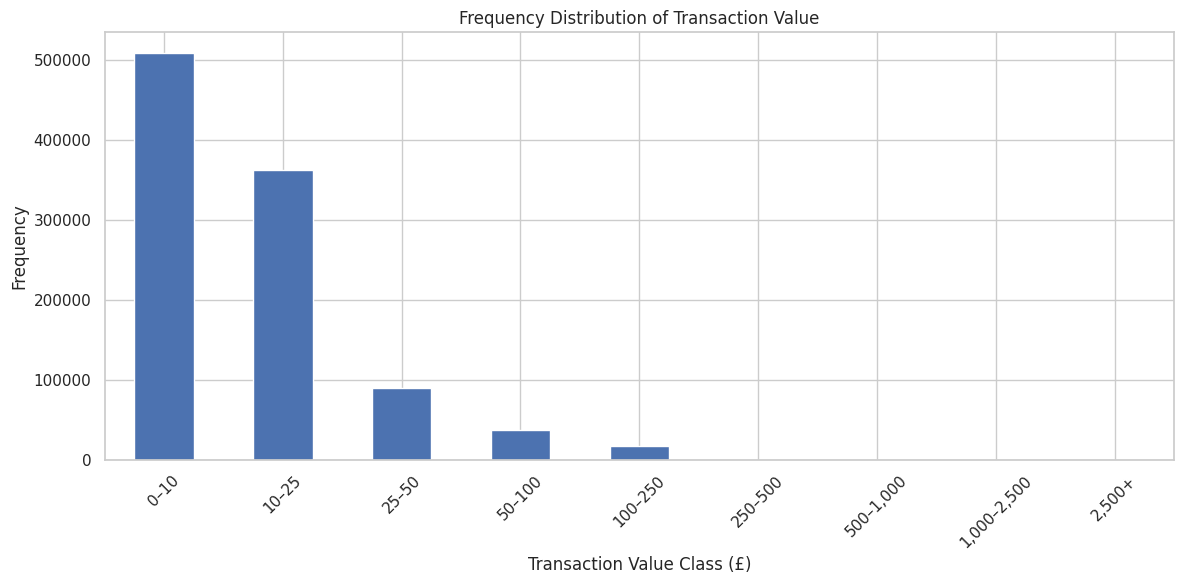

In [22]:
# ============================================================
# STEP 20 — FREQUENCY DISTRIBUTION GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

frequency_table["Frequency"].plot(
    kind="bar"
)

plt.title(
    "Frequency Distribution of Transaction Value"
)

plt.xlabel(
    "Transaction Value Class (£)"
)

plt.ylabel(
    "Frequency"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [23]:
# ============================================================
# STEP 21 — MEAN, MEDIAN AND MODE
# ============================================================

value = clean["AbsoluteValue"]

mean_value = value.mean()

median_value = value.median()

mode_values = value.mode()

print("MEASURES OF CENTRAL TENDENCY")
print("=" * 60)

print(
    f"Mean transaction value: "
    f"£{mean_value:,.2f}"
)

print(
    f"Median transaction value: "
    f"£{median_value:,.2f}"
)

if len(mode_values) > 0:

    print(
        f"Mode transaction value: "
        f"£{mode_values.iloc[0]:,.2f}"
    )

MEASURES OF CENTRAL TENDENCY
Mean transaction value: £21.36
Median transaction value: £10.08
Mode transaction value: £15.00


In [24]:
# ============================================================
# STEP 22 — CENTRAL TENDENCY TABLE
# ============================================================

central_tendency = pd.DataFrame({

    "Measure": [
        "Mean",
        "Median",
        "Mode"
    ],

    "Value": [
        mean_value,
        median_value,
        mode_values.iloc[0]
        if len(mode_values) > 0
        else np.nan
    ]
})

display(central_tendency)

,Measure,Value
0,Mean,21.3619
1,Median,10.0800
2,Mode,15.0000


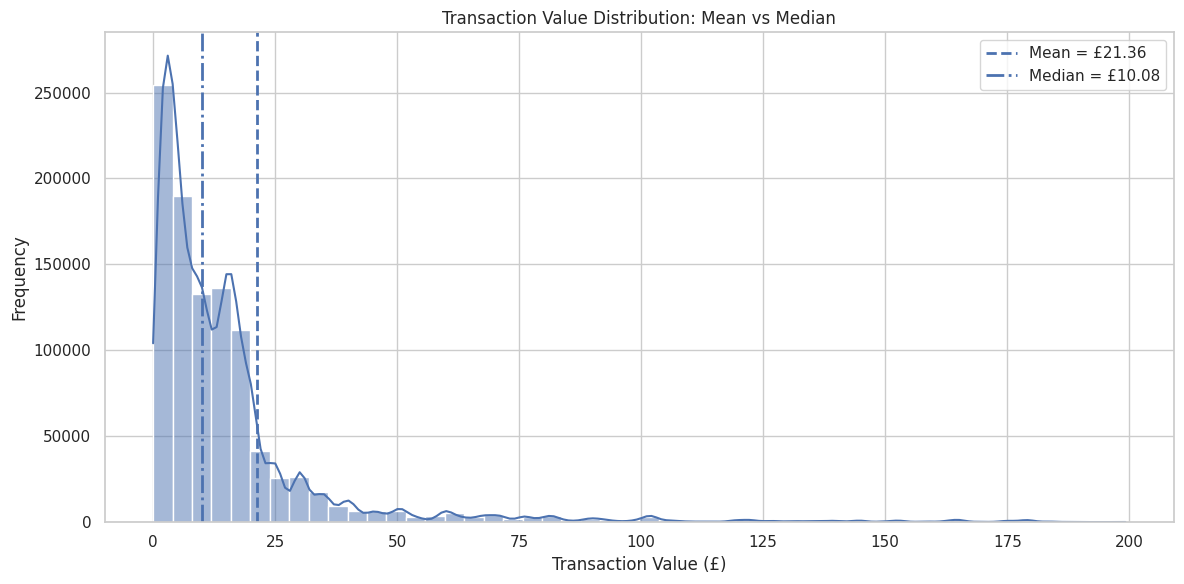

In [25]:
# ============================================================
# STEP 23 — MEAN VS MEDIAN
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    value[
        value <= value.quantile(0.99)
    ],
    bins=50,
    kde=True
)

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = £{mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle="-.",
    linewidth=2,
    label=f"Median = £{median_value:.2f}"
)

plt.title(
    "Transaction Value Distribution: Mean vs Median"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()

plt.show()

In [26]:
# ============================================================
# STEP 24 — RANGE
# ============================================================

minimum_value = value.min()

maximum_value = value.max()

range_value = (
    maximum_value
    - minimum_value
)

print(
    f"Minimum transaction value: "
    f"£{minimum_value:,.2f}"
)

print(
    f"Maximum transaction value: "
    f"£{maximum_value:,.2f}"
)

print(
    f"Range: "
    f"£{range_value:,.2f}"
)

Minimum transaction value: £0.00
Maximum transaction value: £168,469.60
Range: £168,469.60


In [27]:
# ============================================================
# STEP 24 — RANGE
# ============================================================

minimum_value = value.min()

maximum_value = value.max()

range_value = (
    maximum_value
    - minimum_value
)

print(
    f"Minimum transaction value: "
    f"£{minimum_value:,.2f}"
)

print(
    f"Maximum transaction value: "
    f"£{maximum_value:,.2f}"
)

print(
    f"Range: "
    f"£{range_value:,.2f}"
)

Minimum transaction value: £0.00
Maximum transaction value: £168,469.60
Range: £168,469.60


In [28]:
# ============================================================
# STEP 25 — VARIANCE AND STANDARD DEVIATION
# ============================================================

variance_value = value.var(
    ddof=1
)

standard_deviation = value.std(
    ddof=1
)

print(
    f"Variance: "
    f"{variance_value:,.4f}"
)

print(
    f"Standard deviation: "
    f"£{standard_deviation:,.2f}"
)

Variance: 81,423.8739
Standard deviation: £285.35


In [29]:
# ============================================================
# STEP 26 — DISPERSION SUMMARY
# ============================================================

dispersion_table = pd.DataFrame({

    "Measure": [
        "Minimum",
        "Maximum",
        "Range",
        "Variance",
        "Standard Deviation"
    ],

    "Value": [
        minimum_value,
        maximum_value,
        range_value,
        variance_value,
        standard_deviation
    ]
})

display(dispersion_table)

,Measure,Value
0,Minimum,0.0010
1,Maximum,"168,469.6000"
2,Range,"168,469.5990"
3,Variance,"81,423.8739"
4,Standard Deviation,285.3487


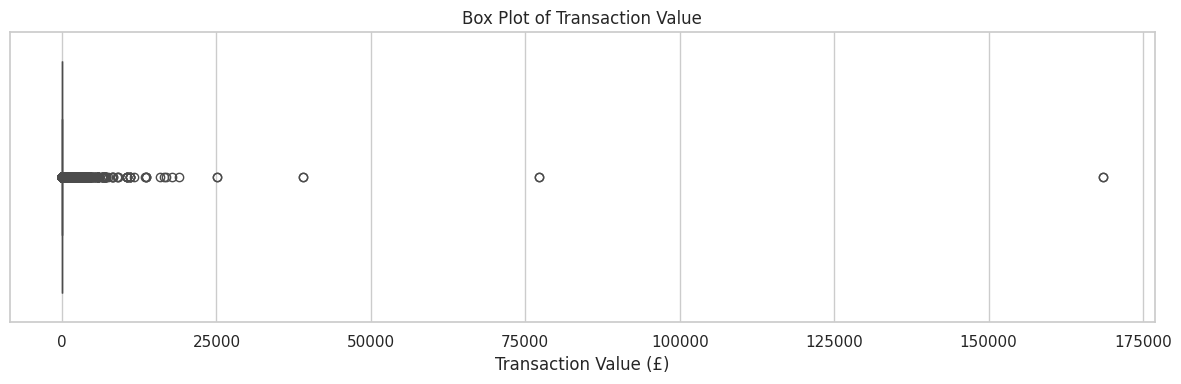

In [30]:
# ============================================================
# STEP 27 — BOX PLOT
# ============================================================

plt.figure(figsize=(12, 4))

sns.boxplot(
    x=value
)

plt.title(
    "Box Plot of Transaction Value"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.show()

In [31]:
# ============================================================
# STEP 28 — QUARTILES AND IQR
# ============================================================

Q1 = value.quantile(0.25)

Q2 = value.quantile(0.50)

Q3 = value.quantile(0.75)

IQR = Q3 - Q1

print(
    f"Q1 = £{Q1:,.2f}"
)

print(
    f"Q2 / Median = £{Q2:,.2f}"
)

print(
    f"Q3 = £{Q3:,.2f}"
)

print(
    f"IQR = £{IQR:,.2f}"
)

Q1 = £4.13
Q2 / Median = £10.08
Q3 = £17.70
IQR = £13.57


In [32]:
# ============================================================
# STEP 29 — QUARTILE TABLE
# ============================================================

quartile_table = pd.DataFrame({

    "Measure": [
        "Q1",
        "Q2 / Median",
        "Q3",
        "IQR"
    ],

    "Value": [
        Q1,
        Q2,
        Q3,
        IQR
    ]
})

display(quartile_table)

,Measure,Value
0,Q1,4.1300
1,Q2 / Median,10.0800
2,Q3,17.7000
3,IQR,13.5700


In [33]:
# ============================================================
# STEP 30 — SKEWNESS
# ============================================================

skewness = value.skew()

print(
    f"Skewness = {skewness:.4f}"
)

if skewness > 0:

    print(
        "Interpretation: Positive / right skewness"
    )

elif skewness < 0:

    print(
        "Interpretation: Negative / left skewness"
    )

else:

    print(
        "Interpretation: Approximately symmetric"
    )

Skewness = 448.4762
Interpretation: Positive / right skewness


In [34]:
# ============================================================
# STEP 31 — COMPLETE DESCRIPTIVE STATISTICS
# ============================================================

descriptive_statistics = pd.DataFrame({

    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Minimum",
        "Maximum",
        "Range",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q2",
        "Q3",
        "IQR",
        "Skewness"
    ],

    "Value": [
        mean_value,
        median_value,
        mode_values.iloc[0]
        if len(mode_values) > 0
        else np.nan,
        minimum_value,
        maximum_value,
        range_value,
        variance_value,
        standard_deviation,
        Q1,
        Q2,
        Q3,
        IQR,
        skewness
    ]
})

display(descriptive_statistics)

,Statistic,Value
0,Mean,21.3619
1,Median,10.0800
2,Mode,15.0000
3,Minimum,0.0010
4,Maximum,"168,469.6000"
5,Range,"168,469.5990"
6,Variance,"81,423.8739"
7,Standard Deviation,285.3487
8,Q1,4.1300
9,Q2,10.0800


In [35]:
# ============================================================
# STEP 32 — FULL DATASET vs 99TH-PERCENTILE VIEW
# ============================================================

# ------------------------------------------------------------
# FULL CLEAN DATASET
# ------------------------------------------------------------
full_data = clean.copy()

# ------------------------------------------------------------
# 99TH-PERCENTILE VIEW
# Used ONLY for selected visualisations and sensitivity
# analysis. We are NOT deleting these observations.
# ------------------------------------------------------------

p99 = full_data["AbsoluteValue"].quantile(0.99)

view_99 = full_data[
    full_data["AbsoluteValue"] <= p99
].copy()

print("DATASET COMPARISON")
print("=" * 65)

print(
    f"Full cleaned dataset      : {len(full_data):,} records"
)

print(
    f"99th-percentile view      : {len(view_99):,} records"
)

print(
    f"99th-percentile threshold : £{p99:,.2f}"
)

print(
    f"Records above P99         : "
    f"{len(full_data) - len(view_99):,}"
)

print(
    f"Percentage above P99      : "
    f"{(len(full_data)-len(view_99))/len(full_data)*100:.2f}%"
)

DATASET COMPARISON
Full cleaned dataset      : 1,027,017 records
99th-percentile view      : 1,016,766 records
99th-percentile threshold : £199.20
Records above P99         : 10,251
Percentage above P99      : 1.00%


In [36]:
# ============================================================
# STEP 33 — VERIFY EXTREME VALUES ARE RETAINED
# ============================================================

print("FULL DATASET")
print("=" * 60)

print(
    f"Maximum transaction value: "
    f"£{full_data['AbsoluteValue'].max():,.2f}"
)

print("\n99TH-PERCENTILE VIEW")

print(
    f"Maximum transaction value: "
    f"£{view_99['AbsoluteValue'].max():,.2f}"
)

print("\nOriginal full dataset is still available as:")
print("full_data")

print("\n99th-percentile analytical view is:")
print("view_99")

FULL DATASET
Maximum transaction value: £168,469.60

99TH-PERCENTILE VIEW
Maximum transaction value: £199.20

Original full dataset is still available as:
full_data

99th-percentile analytical view is:
view_99


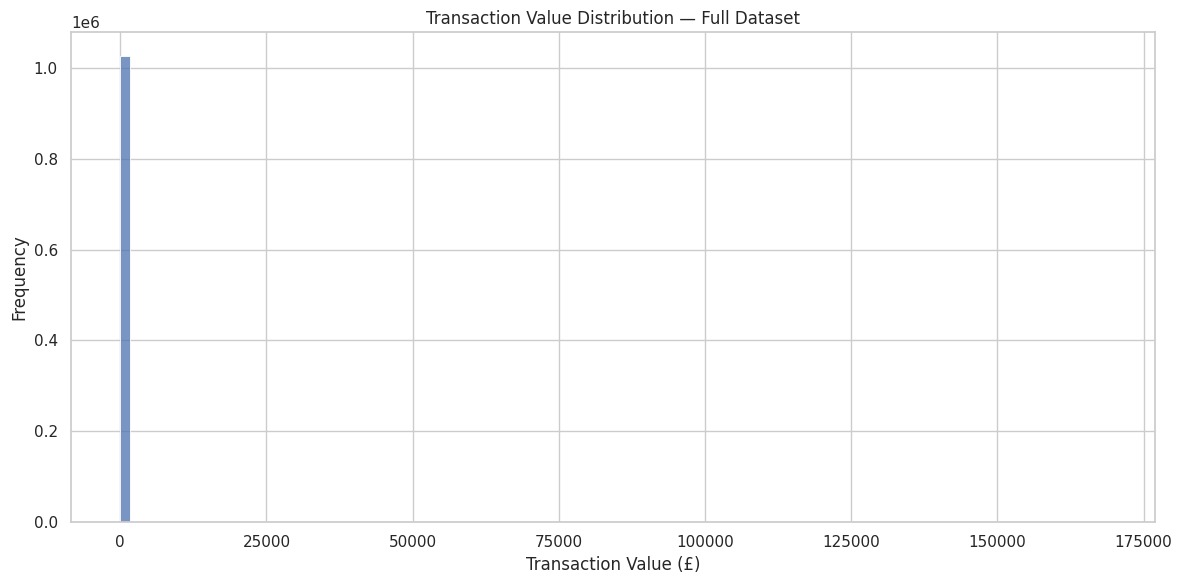

In [37]:
# ============================================================
# STEP 34 — FULL DATASET HISTOGRAM
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    full_data["AbsoluteValue"],
    bins=100
)

plt.title(
    "Transaction Value Distribution — Full Dataset"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

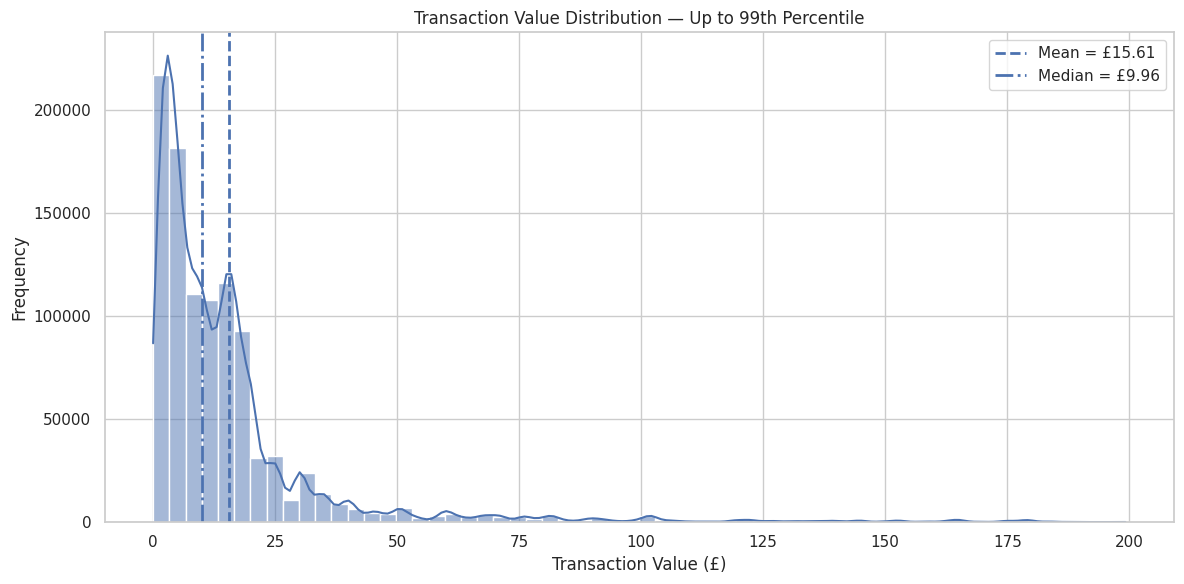

In [38]:
# ============================================================
# STEP 35 — 99TH-PERCENTILE HISTOGRAM
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    view_99["AbsoluteValue"],
    bins=60,
    kde=True
)

plt.axvline(
    view_99["AbsoluteValue"].mean(),
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean = "
        f"£{view_99['AbsoluteValue'].mean():.2f}"
    )
)

plt.axvline(
    view_99["AbsoluteValue"].median(),
    linestyle="-.",
    linewidth=2,
    label=(
        f"Median = "
        f"£{view_99['AbsoluteValue'].median():.2f}"
    )
)

plt.title(
    "Transaction Value Distribution — Up to 99th Percentile"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()

plt.show()

In [39]:
# ============================================================
# STEP 36 — FULL DATA vs 99TH PERCENTILE COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR",
        "Skewness",
        "Maximum"
    ],

    "Full Dataset": [
        full_data["AbsoluteValue"].mean(),
        full_data["AbsoluteValue"].median(),
        full_data["AbsoluteValue"].std(),
        full_data["AbsoluteValue"].quantile(0.25),
        full_data["AbsoluteValue"].quantile(0.75),
        (
            full_data["AbsoluteValue"].quantile(0.75)
            -
            full_data["AbsoluteValue"].quantile(0.25)
        ),
        full_data["AbsoluteValue"].skew(),
        full_data["AbsoluteValue"].max()
    ],

    "99th Percentile View": [
        view_99["AbsoluteValue"].mean(),
        view_99["AbsoluteValue"].median(),
        view_99["AbsoluteValue"].std(),
        view_99["AbsoluteValue"].quantile(0.25),
        view_99["AbsoluteValue"].quantile(0.75),
        (
            view_99["AbsoluteValue"].quantile(0.75)
            -
            view_99["AbsoluteValue"].quantile(0.25)
        ),
        view_99["AbsoluteValue"].skew(),
        view_99["AbsoluteValue"].max()
    ]
})

display(comparison)

,Statistic,Full Dataset,99th Percentile View
0,Mean,21.3619,15.6123
1,Median,10.0800,9.9600
2,Standard Deviation,285.3487,21.8607
3,Q1,4.1300,3.9500
4,Q3,17.7000,17.7000
5,IQR,13.5700,13.7500
6,Skewness,448.4762,4.0405
7,Maximum,"168,469.6000",199.2000


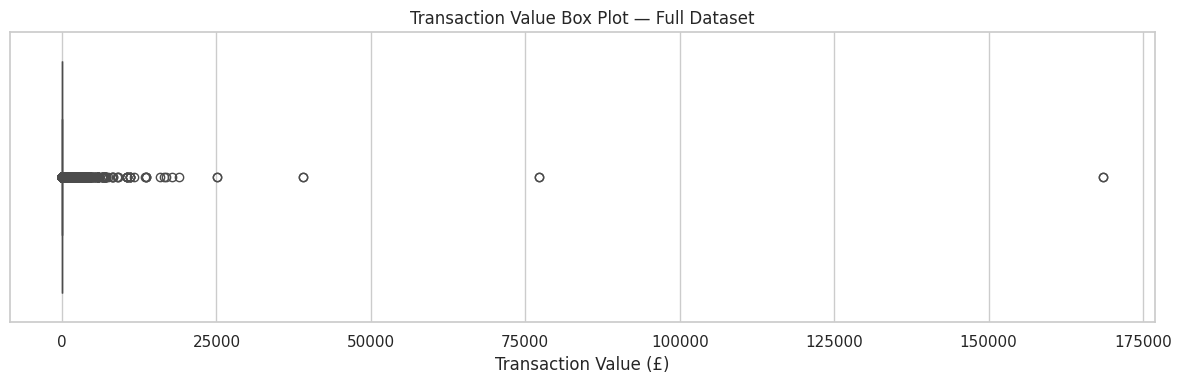

In [40]:
# ============================================================
# STEP 37 — FULL DATASET BOX PLOT
# ============================================================

plt.figure(figsize=(12, 4))

sns.boxplot(
    x=full_data["AbsoluteValue"]
)

plt.title(
    "Transaction Value Box Plot — Full Dataset"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.show()

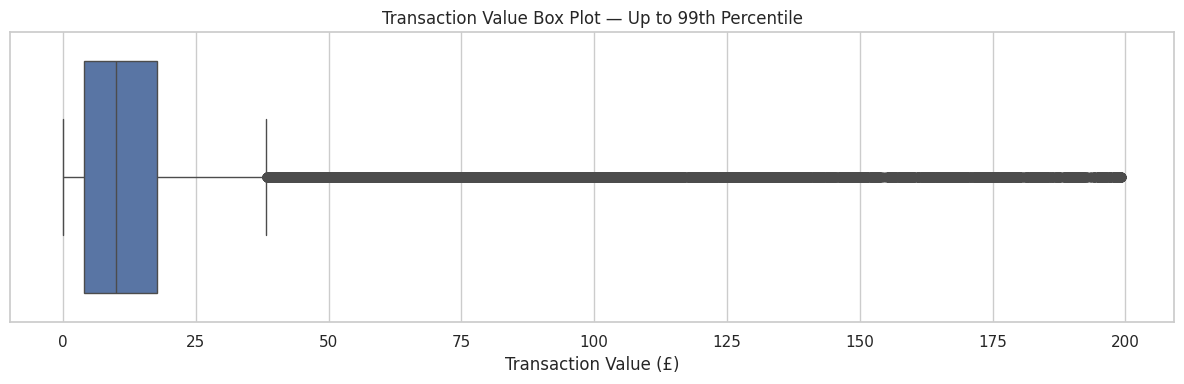

In [41]:
# ============================================================
# STEP 38 — 99TH-PERCENTILE BOX PLOT
# ============================================================

plt.figure(figsize=(12, 4))

sns.boxplot(
    x=view_99["AbsoluteValue"]
)

plt.title(
    "Transaction Value Box Plot — Up to 99th Percentile"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.show()

In [42]:
# ============================================================
# STEP 39 — BIVARIATE ANALYSIS DATA
# ============================================================

bivariate_full = full_data[
    [
        "Quantity",
        "AbsoluteValue"
    ]
].dropna()

bivariate_99 = view_99[
    [
        "Quantity",
        "AbsoluteValue"
    ]
].dropna()

print(
    "Full bivariate observations:",
    f"{len(bivariate_full):,}"
)

print(
    "99th-percentile observations:",
    f"{len(bivariate_99):,}"
)

Full bivariate observations: 1,027,017
99th-percentile observations: 1,016,766


In [43]:
# ============================================================
# STEP 40 — PEARSON CORRELATION: FULL DATASET
# ============================================================

r_full, p_full = stats.pearsonr(
    bivariate_full["Quantity"],
    bivariate_full["AbsoluteValue"]
)

print("PEARSON CORRELATION — FULL DATASET")
print("=" * 60)

print(
    f"Pearson correlation (r): {r_full:.4f}"
)

print(
    f"p-value: {p_full:.6g}"
)

PEARSON CORRELATION — FULL DATASET
Pearson correlation (r): 0.0397
p-value: 0


In [44]:
# ============================================================
# STEP 41 — PEARSON CORRELATION: 99TH-PERCENTILE VIEW
# ============================================================

r_99, p_99 = stats.pearsonr(
    bivariate_99["Quantity"],
    bivariate_99["AbsoluteValue"]
)

print("PEARSON CORRELATION — 99TH-PERCENTILE VIEW")
print("=" * 60)

print(
    f"Pearson correlation (r): {r_99:.4f}"
)

print(
    f"p-value: {p_99:.6g}"
)

PEARSON CORRELATION — 99TH-PERCENTILE VIEW
Pearson correlation (r): 0.4658
p-value: 0


In [45]:
# ============================================================
# STEP 42 — CORRELATION COMPARISON
# ============================================================

correlation_comparison = pd.DataFrame({

    "Dataset": [
        "Full Dataset",
        "99th-Percentile View"
    ],

    "Pearson r": [
        r_full,
        r_99
    ],

    "p-value": [
        p_full,
        p_99
    ]
})

display(correlation_comparison)

,Dataset,Pearson r,p-value
0,Full Dataset,0.0397,0.0000
1,99th-Percentile View,0.4658,0.0000


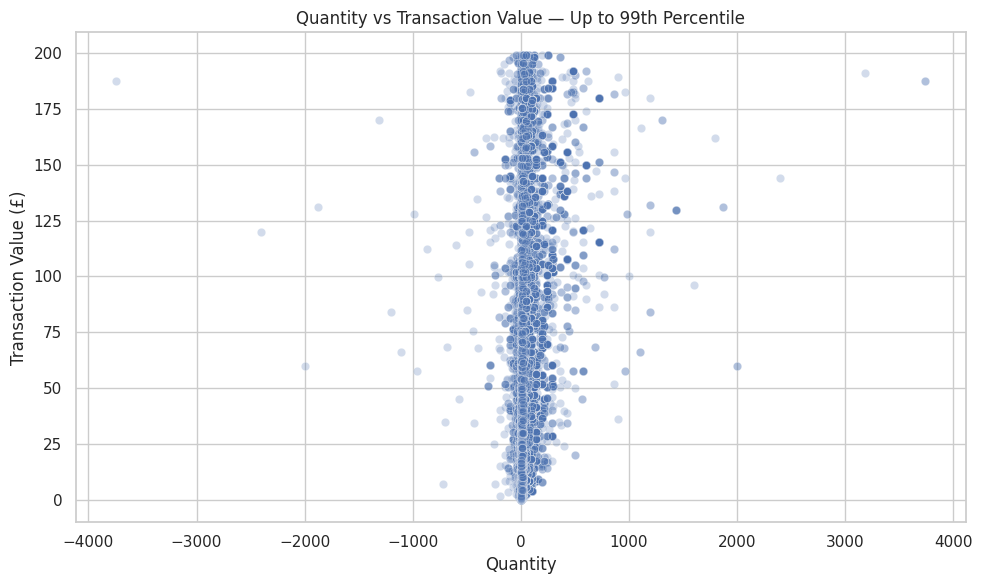

In [46]:
# ============================================================
# STEP 43 — SCATTER PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=bivariate_99,
    x="Quantity",
    y="AbsoluteValue",
    alpha=0.25
)

plt.title(
    "Quantity vs Transaction Value — Up to 99th Percentile"
)

plt.xlabel(
    "Quantity"
)

plt.ylabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.show()

In [47]:
# ============================================================
# STEP 44 — LINEAR REGRESSION: FULL DATASET
# ============================================================

X_full = sm.add_constant(
    bivariate_full["Quantity"]
)

Y_full = (
    bivariate_full["AbsoluteValue"]
)

model_full = sm.OLS(
    Y_full,
    X_full
).fit()

print(
    model_full.summary()
)

                            OLS Regression Results                            
Dep. Variable:          AbsoluteValue   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1623.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        23:58:19   Log-Likelihood:            -7.2629e+06
No. Observations:             1027017   AIC:                         1.453e+07
Df Residuals:                 1027015   BIC:                         1.453e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.6599      0.282     73.291      0.0

In [48]:
# ============================================================
# STEP 45 — FULL REGRESSION COEFFICIENTS
# ============================================================

intercept_full = model_full.params["const"]

slope_full = model_full.params["Quantity"]

r2_full = model_full.rsquared

print(
    f"Intercept = {intercept_full:.4f}"
)

print(
    f"Quantity coefficient = {slope_full:.4f}"
)

print(
    f"R² = {r2_full:.4f}"
)

print(
    "\nRegression equation:"
)

print(
    f"Transaction Value = "
    f"{intercept_full:.4f} + "
    f"{slope_full:.4f} × Quantity"
)

Intercept = 20.6599
Quantity coefficient = 0.0672
R² = 0.0016

Regression equation:
Transaction Value = 20.6599 + 0.0672 × Quantity


In [49]:
# ============================================================
# STEP 46 — LINEAR REGRESSION: 99TH-PERCENTILE VIEW
# ============================================================

X_99 = sm.add_constant(
    bivariate_99["Quantity"]
)

Y_99 = (
    bivariate_99["AbsoluteValue"]
)

model_99 = sm.OLS(
    Y_99,
    X_99
).fit()

intercept_99 = model_99.params["const"]

slope_99 = model_99.params["Quantity"]

r2_99 = model_99.rsquared

print(
    f"Intercept = {intercept_99:.4f}"
)

print(
    f"Quantity coefficient = {slope_99:.4f}"
)

print(
    f"R² = {r2_99:.4f}"
)

print(
    "\nRegression equation:"
)

print(
    f"Transaction Value = "
    f"{intercept_99:.4f} + "
    f"{slope_99:.4f} × Quantity"
)

Intercept = 11.8147
Quantity coefficient = 0.4476
R² = 0.2170

Regression equation:
Transaction Value = 11.8147 + 0.4476 × Quantity


In [50]:
# ============================================================
# STEP 47 — REGRESSION COMPARISON
# ============================================================

regression_comparison = pd.DataFrame({

    "Metric": [
        "Intercept",
        "Quantity Coefficient",
        "R²"
    ],

    "Full Dataset": [
        intercept_full,
        slope_full,
        r2_full
    ],

    "99th-Percentile View": [
        intercept_99,
        slope_99,
        r2_99
    ]
})

display(regression_comparison)

,Metric,Full Dataset,99th-Percentile View
0,Intercept,20.6599,11.8147
1,Quantity Coefficient,0.0672,0.4476
2,R²,0.0016,0.2170


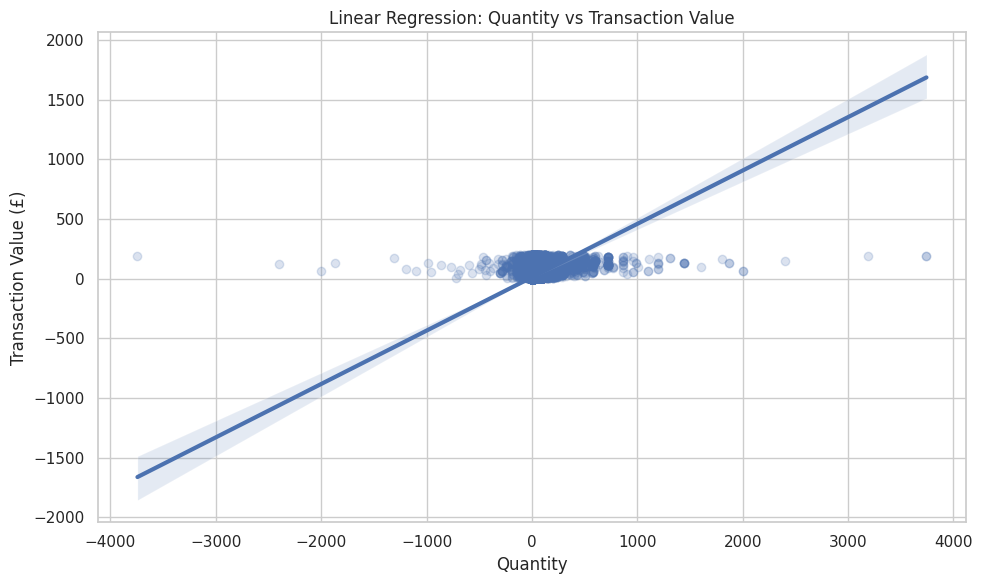

In [51]:
# ============================================================
# STEP 48 — REGRESSION PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=bivariate_99,
    x="Quantity",
    y="AbsoluteValue",
    scatter_kws={
        "alpha": 0.20
    },
    line_kws={
        "linewidth": 3
    }
)

plt.title(
    "Linear Regression: Quantity vs Transaction Value"
)

plt.xlabel(
    "Quantity"
)

plt.ylabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.show()

STEP 49 — BASIC PROBABILITY
Total transactions       : 1,027,017
Completed transactions   : 1,007,913
Cancelled transactions   : 19,104

P(Cancellation)          : 1.8601%
P(Completed)             : 98.1399%
P(Cancelled) + P(Completed): 100.0000%

STEP 50 — CONDITIONAL PROBABILITY
90th percentile threshold : £33.26
High-value transactions   : 102,881
High-value cancellations  : 2,761

P(Cancellation | High-value): 2.6837%
P(Cancellation)            : 1.8601%


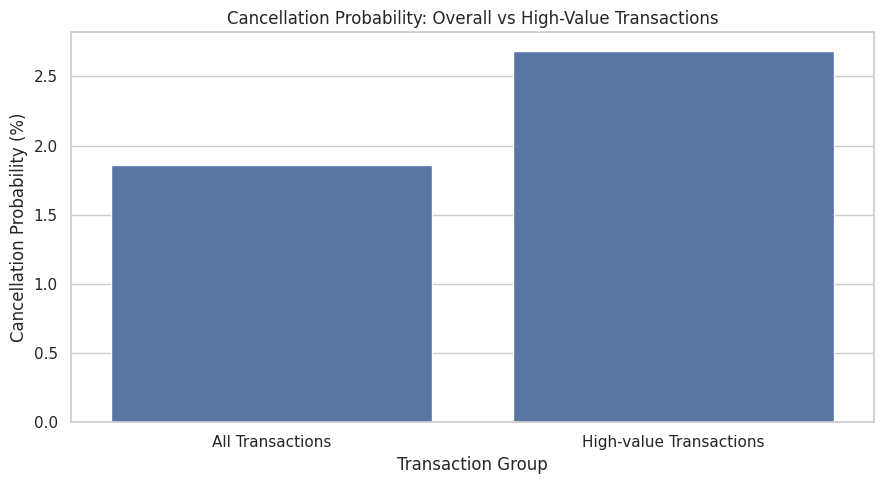


STEP 51 — STANDARD NORMAL DISTRIBUTION


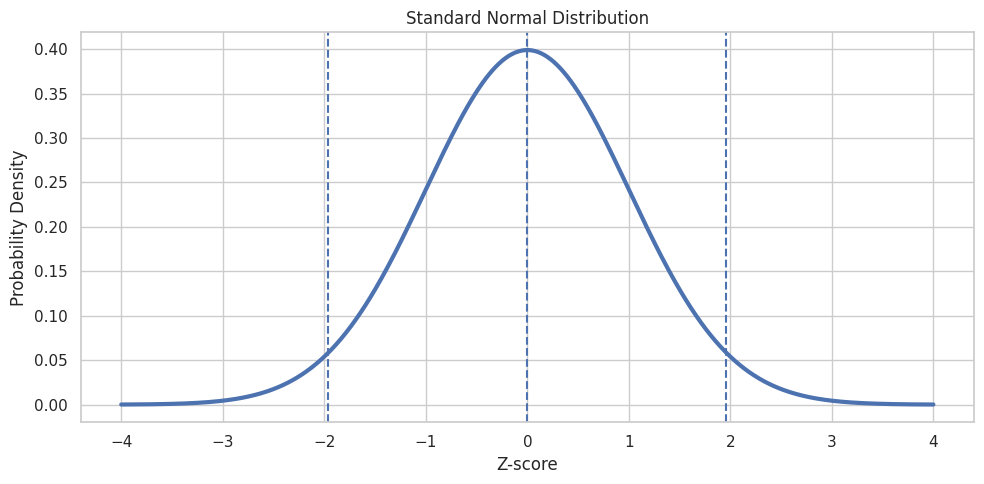

P(-1.96 < Z < 1.96) = 0.9500
Approximately 95% of a standard normal distribution lies between -1.96 and +1.96.

STEP 52 — CENTRAL LIMIT THEOREM
Population mean          : £21.3619
Mean of sample means     : £21.2226
SD of sample means       : £16.7547

Number of samples        : 1,000
Sample size               : 100


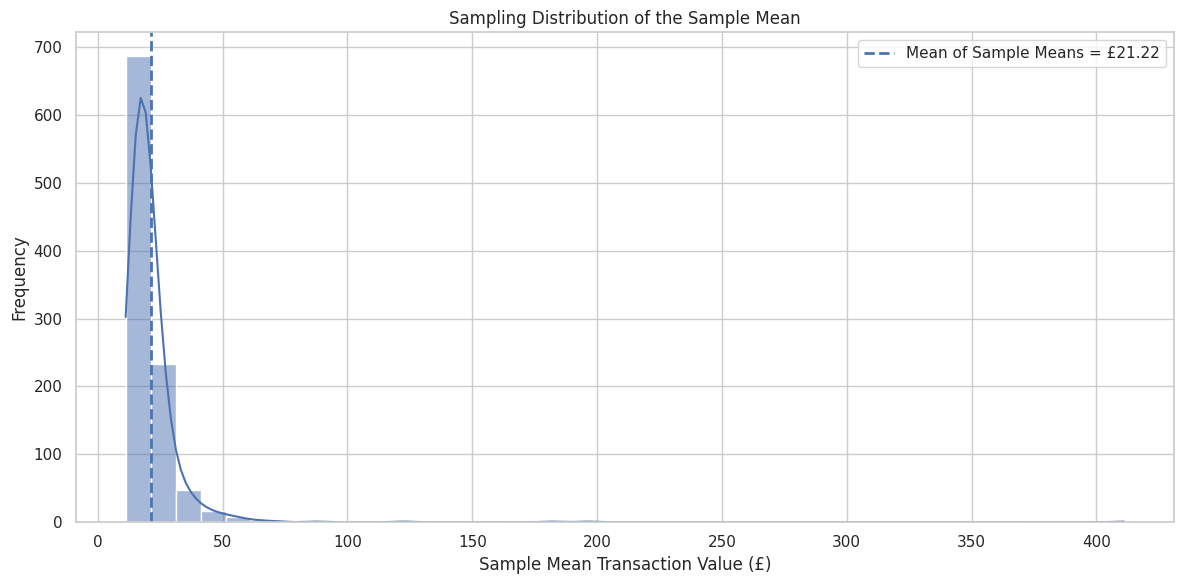


STEP 53 — 95% CONFIDENCE INTERVAL
Sample size             : 500
Sample mean             : £20.5978
Sample standard deviation: £73.9188
Standard error          : £3.3058
t-critical              : 1.9647
Margin of error         : £6.4949

95% CI lower limit      : £14.1029
95% CI upper limit      : £27.0927


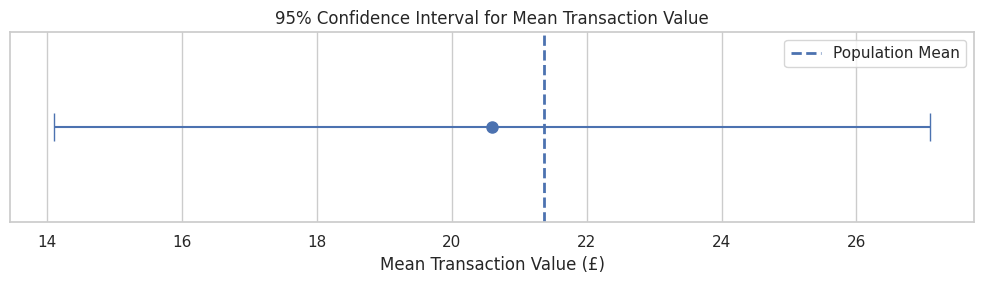


STEP 54 — WELCH'S INDEPENDENT-SAMPLES t-TEST
Completed mean         : £20.3155
Cancelled mean         : £76.5702

t-statistic            : -5.3122
p-value                : 1.09529e-07

Decision: Reject H0.
There is statistically significant evidence that the two mean transaction values differ.

STEP 55 — t-TEST SENSITIVITY ANALYSIS
99th-percentile completed mean : £15.5941
99th-percentile cancelled mean : £16.5992

t-statistic                    : -5.1531
p-value                        : 2.58787e-07

STEP 56 — TYPE I AND TYPE II ERRORS

TYPE I ERROR
------------
A Type I error occurs when we reject H0 even though H0 is
actually true.

In this project:
We could incorrectly conclude that completed and cancelled
transactions have different mean transaction values when
there is actually no population difference.

TYPE II ERROR
-------------
A Type II error occurs when we fail to reject H0 even though
H1 is actually true.

In this project:
We could fail to detect a genuine difference betwe

,count,mean,median
Weekday,,,
Monday,182646,21.0611,9.9000
Tuesday,190555,23.2584,10.2000
Wednesday,176365,20.7497,10.2000
Thursday,195050,22.8163,10.9000
Friday,149005,24.9752,10.4000
Saturday,400,24.5076,17.7000
Sunday,132996,13.6791,7.5000


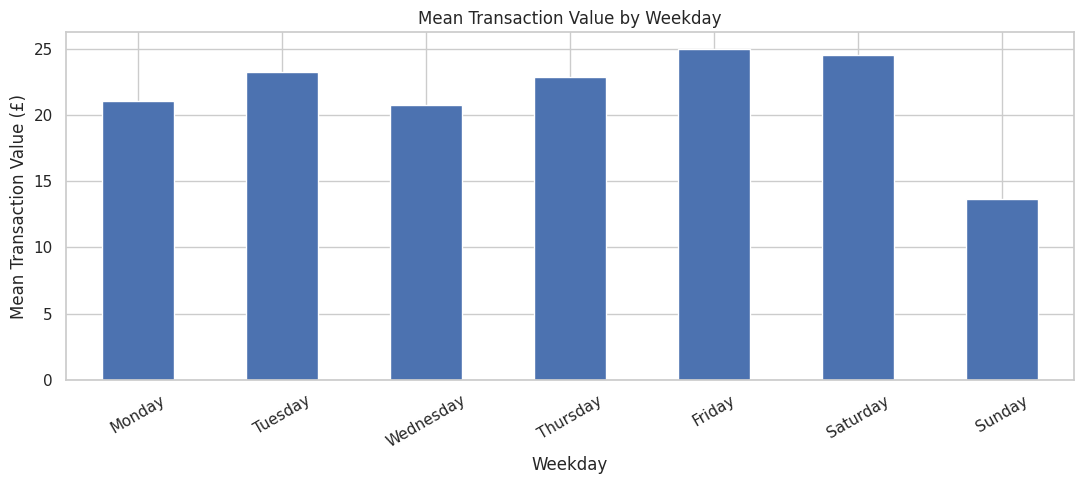


STEP 58 — CHI-SQUARE TEST


,Completed,Cancelled
Weekday,,
Monday,179603,3043
Tuesday,186402,4153
Wednesday,173059,3306
Thursday,190465,4585
Friday,146072,2933
Saturday,400,0
Sunday,131912,1084


Chi-square statistic : 1214.2293
Degrees of freedom   : 6
p-value              : 3.98477e-259

Decision: Reject H0.
There is statistically significant evidence of an association between weekday and cancellation.

Cancellation rate by weekday (%):


,Cancellation Rate (%)
Weekday,
Monday,1.6661
Tuesday,2.1794
Wednesday,1.8745
Thursday,2.3507
Friday,1.9684
Saturday,0.0000
Sunday,0.8151


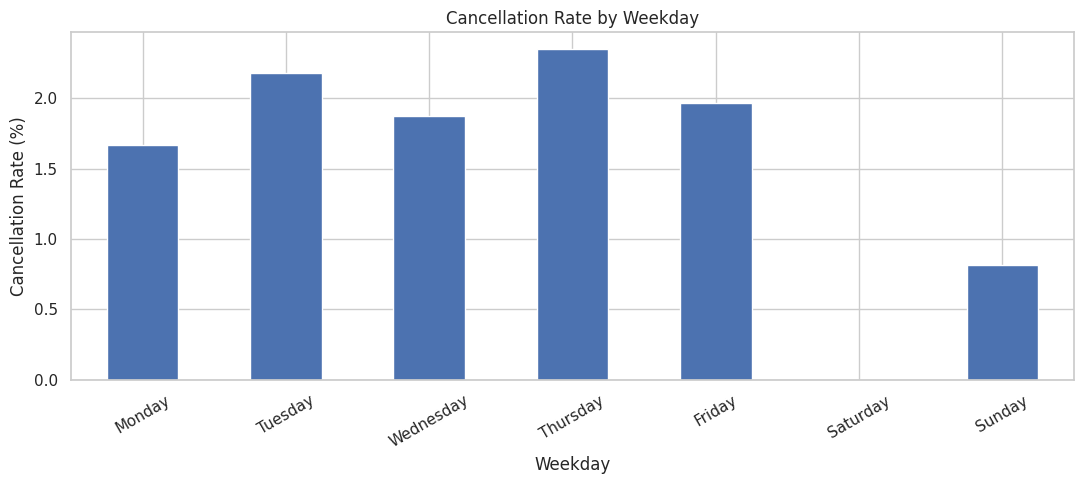


STEP 59 — MANN-WHITNEY U TEST
U statistic : 9,765,796,516
p-value     : 0.000662003

Decision: Reject H0.
The distributions of transaction values for completed and cancelled transactions differ statistically significantly.


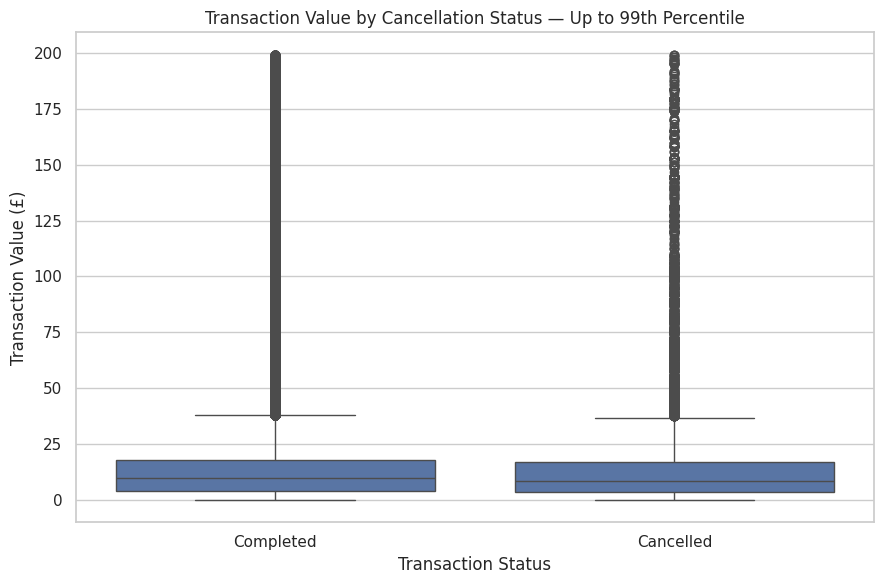


STEP 60 — FINAL STATISTICAL RESULTS


,Analysis,Statistic,p-value,Significant at 5%
0,Pearson Correlation,0.0397,0.0000,Yes
1,Pearson Correlation — 99th Percentile,0.4658,0.0000,Yes
2,Welch t-test,-5.3122,0.0000,Yes
3,Welch t-test — 99th Percentile,-5.1531,0.0000,Yes
4,One-way ANOVA,22.4781,0.0000,Yes
5,Chi-square,"1,214.2293",0.0000,Yes
6,Mann-Whitney U,"9,765,796,516.5000",0.0007,Yes



FINAL BUSINESS STATISTICAL SUMMARY

DATASET
-------
Full analytical observations : 1,027,017
99th-percentile threshold    : £199.20
Observations above P99        : 10,251

DESCRIPTIVE STATISTICS
----------------------
Mean                        : £21.36
Median                      : £10.08
Standard deviation           : £285.35
Q1                           : £4.13
Q3                           : £17.70
Skewness                     : 448.4762

PROBABILITY
-----------
Overall cancellation probability:
1.86%

High-value cancellation probability:
2.68%

CORRELATION
-----------
Full-data Pearson r:
0.0397

99th-percentile Pearson r:
0.4658

REGRESSION
----------
Full-data R²:
0.0016

99th-percentile R²:
0.2170

HYPOTHESIS TESTING
------------------
Welch t-test p-value:
1.09529e-07

ANOVA p-value:
1.21631e-26

Chi-square p-value:
3.98477e-259

Mann-Whitney U p-value:
0.000662003


SAVING RESULTS

Results saved to:
/content/business_statistics_results

ZIP file created:
/content/business_st

In [52]:
# ============================================================
# STEPS 49–60
# PROBABILITY + CLT + CONFIDENCE INTERVAL
# + HYPOTHESIS TESTING + FINAL SUMMARY
# ============================================================
#
# IMPORTANT:
# This cell assumes that Steps 1–48 have already been executed.
#
# Existing important objects:
#   clean      -> cleaned dataset
#   full_data  -> complete cleaned dataset
#   view_99    -> observations up to 99th percentile
#   p99        -> 99th percentile threshold
#
# ============================================================


# ============================================================
# STEP 49 — BASIC PROBABILITY
# ============================================================
#
# Business question:
# What is the probability that a transaction is cancelled?
#
# Formula:
#
# P(Cancellation)
# =
# Number of Cancelled Transactions
# ---------------------------------
# Total Number of Transactions
#
# ============================================================

print("=" * 75)
print("STEP 49 — BASIC PROBABILITY")
print("=" * 75)

total_transactions = len(full_data)

cancelled_transactions = (
    full_data["Cancelled"].sum()
)

completed_transactions = (
    total_transactions
    - cancelled_transactions
)

P_cancelled = (
    cancelled_transactions
    / total_transactions
)

P_completed = (
    completed_transactions
    / total_transactions
)

print(
    f"Total transactions       : {total_transactions:,}"
)

print(
    f"Completed transactions   : {completed_transactions:,}"
)

print(
    f"Cancelled transactions   : {cancelled_transactions:,}"
)

print(
    f"\nP(Cancellation)          : {P_cancelled:.4%}"
)

print(
    f"P(Completed)             : {P_completed:.4%}"
)

print(
    f"P(Cancelled) + P(Completed): "
    f"{P_cancelled + P_completed:.4%}"
)


# ============================================================
# STEP 50 — CONDITIONAL PROBABILITY
# ============================================================
#
# We define a "high-value transaction" as a transaction
# belonging to the top 10% of transaction values.
#
# Therefore:
#
# High-value threshold = 90th percentile
#
# We calculate:
#
# P(Cancellation | High-value transaction)
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 50 — CONDITIONAL PROBABILITY")
print("=" * 75)

high_value_threshold = (
    full_data["AbsoluteValue"]
    .quantile(0.90)
)

full_data["HighValue"] = (
    full_data["AbsoluteValue"]
    >= high_value_threshold
)

high_value_transactions = (
    full_data["HighValue"].sum()
)

high_value_cancelled = (
    full_data.loc[
        full_data["HighValue"],
        "Cancelled"
    ].sum()
)

P_cancelled_given_high = (
    high_value_cancelled
    / high_value_transactions
)

print(
    f"90th percentile threshold : "
    f"£{high_value_threshold:,.2f}"
)

print(
    f"High-value transactions   : "
    f"{high_value_transactions:,}"
)

print(
    f"High-value cancellations  : "
    f"{high_value_cancelled:,}"
)

print(
    f"\nP(Cancellation | High-value): "
    f"{P_cancelled_given_high:.4%}"
)

print(
    f"P(Cancellation)            : "
    f"{P_cancelled:.4%}"
)


# ============================================================
# GRAPH — PROBABILITY COMPARISON
# ============================================================

probability_comparison = pd.DataFrame({

    "Group": [
        "All Transactions",
        "High-value Transactions"
    ],

    "Cancellation Probability (%)": [
        P_cancelled * 100,
        P_cancelled_given_high * 100
    ]
})

plt.figure(figsize=(9, 5))

sns.barplot(
    data=probability_comparison,
    x="Group",
    y="Cancellation Probability (%)"
)

plt.title(
    "Cancellation Probability: Overall vs High-Value Transactions"
)

plt.xlabel("Transaction Group")

plt.ylabel(
    "Cancellation Probability (%)"
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 51 — NORMAL DISTRIBUTION
# ============================================================
#
# The original transaction-value data are NOT normally
# distributed, as demonstrated by the very high skewness.
#
# Therefore, we do NOT claim that transaction values themselves
# follow a normal distribution.
#
# Instead, we demonstrate the theoretical Standard Normal
# Distribution used in statistical inference.
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 51 — STANDARD NORMAL DISTRIBUTION")
print("=" * 75)

z_values = np.linspace(
    -4,
    4,
    500
)

normal_density = norm.pdf(
    z_values
)

plt.figure(figsize=(10, 5))

plt.plot(
    z_values,
    normal_density,
    linewidth=3
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.axvline(
    -1.96,
    linestyle="--",
    linewidth=1.5
)

plt.axvline(
    1.96,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Standard Normal Distribution"
)

plt.xlabel(
    "Z-score"
)

plt.ylabel(
    "Probability Density"
)

plt.tight_layout()

plt.show()

probability_95 = (
    norm.cdf(1.96)
    - norm.cdf(-1.96)
)

print(
    f"P(-1.96 < Z < 1.96) = "
    f"{probability_95:.4f}"
)

print(
    "Approximately 95% of a standard normal distribution "
    "lies between -1.96 and +1.96."
)


# ============================================================
# STEP 52 — CENTRAL LIMIT THEOREM
# ============================================================
#
# We repeatedly take samples from the transaction population
# and calculate their means.
#
# The purpose is to demonstrate the sampling distribution
# of the sample mean.
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 52 — CENTRAL LIMIT THEOREM")
print("=" * 75)

np.random.seed(42)

population_values = (
    full_data["AbsoluteValue"]
    .values
)

sample_size = 100

number_of_samples = 1000

sample_means = []

for i in range(number_of_samples):

    random_sample = np.random.choice(
        population_values,
        size=sample_size,
        replace=True
    )

    sample_means.append(
        random_sample.mean()
    )

sample_means = np.array(
    sample_means
)

population_mean = (
    population_values.mean()
)

sampling_mean = (
    sample_means.mean()
)

sampling_std = (
    sample_means.std(ddof=1)
)

print(
    f"Population mean          : "
    f"£{population_mean:,.4f}"
)

print(
    f"Mean of sample means     : "
    f"£{sampling_mean:,.4f}"
)

print(
    f"SD of sample means       : "
    f"£{sampling_std:,.4f}"
)

print(
    f"\nNumber of samples        : "
    f"{number_of_samples:,}"
)

print(
    f"Sample size               : "
    f"{sample_size}"
)


# ============================================================
# GRAPH — SAMPLING DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    sample_means,
    bins=40,
    kde=True
)

plt.axvline(
    sampling_mean,
    linestyle="--",
    linewidth=2,
    label=(
        f"Mean of Sample Means = "
        f"£{sampling_mean:.2f}"
    )
)

plt.title(
    "Sampling Distribution of the Sample Mean"
)

plt.xlabel(
    "Sample Mean Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# STEP 53 — 95% CONFIDENCE INTERVAL
# ============================================================
#
# We use a random sample of 500 observations.
#
# Formula:
#
# CI = x̄ ± t(α/2) × (s / √n)
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 53 — 95% CONFIDENCE INTERVAL")
print("=" * 75)

np.random.seed(123)

ci_sample = np.random.choice(
    population_values,
    size=500,
    replace=True
)

ci_n = len(ci_sample)

ci_mean = (
    ci_sample.mean()
)

ci_sd = (
    ci_sample.std(ddof=1)
)

ci_standard_error = (
    ci_sd / np.sqrt(ci_n)
)

ci_t_critical = t.ppf(
    0.975,
    df=ci_n - 1
)

ci_margin_error = (
    ci_t_critical
    * ci_standard_error
)

ci_lower = (
    ci_mean
    - ci_margin_error
)

ci_upper = (
    ci_mean
    + ci_margin_error
)

print(
    f"Sample size             : {ci_n}"
)

print(
    f"Sample mean             : £{ci_mean:,.4f}"
)

print(
    f"Sample standard deviation: £{ci_sd:,.4f}"
)

print(
    f"Standard error          : £{ci_standard_error:,.4f}"
)

print(
    f"t-critical              : {ci_t_critical:.4f}"
)

print(
    f"Margin of error         : £{ci_margin_error:,.4f}"
)

print(
    f"\n95% CI lower limit      : £{ci_lower:,.4f}"
)

print(
    f"95% CI upper limit      : £{ci_upper:,.4f}"
)


# ============================================================
# GRAPH — CONFIDENCE INTERVAL
# ============================================================

plt.figure(figsize=(10, 3))

plt.errorbar(
    ci_mean,
    0,
    xerr=ci_margin_error,
    fmt="o",
    capsize=10,
    markersize=8
)

plt.axvline(
    population_mean,
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.yticks([])

plt.xlabel(
    "Mean Transaction Value (£)"
)

plt.title(
    "95% Confidence Interval for Mean Transaction Value"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# STEP 54 — WELCH'S INDEPENDENT-SAMPLES t-TEST
# ============================================================
#
# Business question:
#
# Is the transaction value significantly different between
# completed and cancelled transactions?
#
# H0:
# Mean completed transaction value =
# Mean cancelled transaction value
#
# H1:
# The two means are different.
#
# We use Welch's t-test because it does not require equal
# population variances.
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 54 — WELCH'S INDEPENDENT-SAMPLES t-TEST")
print("=" * 75)

completed_values = (
    full_data.loc[
        full_data["Cancelled"] == False,
        "AbsoluteValue"
    ]
)

cancelled_values = (
    full_data.loc[
        full_data["Cancelled"] == True,
        "AbsoluteValue"
    ]
)

t_stat, t_pvalue = stats.ttest_ind(
    completed_values,
    cancelled_values,
    equal_var=False
)

print(
    f"Completed mean         : "
    f"£{completed_values.mean():,.4f}"
)

print(
    f"Cancelled mean         : "
    f"£{cancelled_values.mean():,.4f}"
)

print(
    f"\nt-statistic            : "
    f"{t_stat:.4f}"
)

print(
    f"p-value                : "
    f"{t_pvalue:.6g}"
)

alpha = 0.05

if t_pvalue < alpha:

    print(
        "\nDecision: Reject H0."
    )

    print(
        "There is statistically significant evidence "
        "that the two mean transaction values differ."
    )

else:

    print(
        "\nDecision: Fail to reject H0."
    )

    print(
        "There is insufficient statistical evidence "
        "to conclude that the two means differ."
    )


# ============================================================
# STEP 55 — t-TEST SENSITIVITY ANALYSIS
# ============================================================
#
# Because the transaction-value distribution is extremely
# skewed, we repeat the t-test on the 99th-percentile view.
#
# This DOES NOT replace the full-data result.
#
# It is a sensitivity analysis.
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 55 — t-TEST SENSITIVITY ANALYSIS")
print("=" * 75)

completed_99 = (
    view_99.loc[
        view_99["Cancelled"] == False,
        "AbsoluteValue"
    ]
)

cancelled_99 = (
    view_99.loc[
        view_99["Cancelled"] == True,
        "AbsoluteValue"
    ]
)

t_stat_99, t_pvalue_99 = stats.ttest_ind(
    completed_99,
    cancelled_99,
    equal_var=False
)

print(
    f"99th-percentile completed mean : "
    f"£{completed_99.mean():,.4f}"
)

print(
    f"99th-percentile cancelled mean : "
    f"£{cancelled_99.mean():,.4f}"
)

print(
    f"\nt-statistic                    : "
    f"{t_stat_99:.4f}"
)

print(
    f"p-value                        : "
    f"{t_pvalue_99:.6g}"
)


# ============================================================
# STEP 56 — TYPE I AND TYPE II ERROR EXPLANATION
# ============================================================

print("\n" + "=" * 75)
print("STEP 56 — TYPE I AND TYPE II ERRORS")
print("=" * 75)

print("""
TYPE I ERROR
------------
A Type I error occurs when we reject H0 even though H0 is
actually true.

In this project:
We could incorrectly conclude that completed and cancelled
transactions have different mean transaction values when
there is actually no population difference.

TYPE II ERROR
-------------
A Type II error occurs when we fail to reject H0 even though
H1 is actually true.

In this project:
We could fail to detect a genuine difference between the
transaction values of completed and cancelled transactions.

SIGNIFICANCE LEVEL
------------------
We use alpha = 0.05.

This means the analysis uses a 5% significance threshold
for hypothesis testing.
""")


# ============================================================
# STEP 57 — ONE-WAY ANOVA
# ============================================================
#
# Business question:
#
# Does mean transaction value differ across weekdays?
#
# H0:
# All weekday means are equal.
#
# H1:
# At least one weekday mean is different.
#
# ============================================================

print("=" * 75)
print("STEP 57 — ONE-WAY ANOVA")
print("=" * 75)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

anova_data = full_data.copy()

anova_groups = []

valid_weekdays = []

for day in weekday_order:

    group = anova_data.loc[
        anova_data["Weekday"] == day,
        "AbsoluteValue"
    ].dropna()

    if len(group) > 0:

        anova_groups.append(group)

        valid_weekdays.append(day)

anova_F, anova_pvalue = stats.f_oneway(
    *anova_groups
)

print(
    f"F-statistic : {anova_F:.4f}"
)

print(
    f"p-value     : {anova_pvalue:.6g}"
)

if anova_pvalue < alpha:

    print(
        "\nDecision: Reject H0."
    )

    print(
        "At least one weekday has a statistically "
        "different mean transaction value."
    )

else:

    print(
        "\nDecision: Fail to reject H0."
    )

    print(
        "There is insufficient evidence that weekday "
        "mean transaction values differ."
    )


# ============================================================
# WEEKDAY MEAN TABLE
# ============================================================

weekday_means = (
    anova_data
    .groupby("Weekday")["AbsoluteValue"]
    .agg(
        ["count", "mean", "median"]
    )
    .reindex(weekday_order)
)

display(weekday_means)


# ============================================================
# GRAPH — WEEKDAY MEANS
# ============================================================

plt.figure(figsize=(11, 5))

weekday_means["mean"].plot(
    kind="bar"
)

plt.title(
    "Mean Transaction Value by Weekday"
)

plt.xlabel(
    "Weekday"
)

plt.ylabel(
    "Mean Transaction Value (£)"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 58 — CHI-SQUARE TEST
# ============================================================
#
# Business question:
#
# Is cancellation status associated with weekday?
#
# H0:
# Cancellation status and weekday are independent.
#
# H1:
# Cancellation status and weekday are associated.
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 58 — CHI-SQUARE TEST")
print("=" * 75)

chi_table = pd.crosstab(
    full_data["Weekday"],
    full_data["Cancelled"]
)

# Make sure all weekdays are shown in logical order.
chi_table = chi_table.reindex(
    weekday_order,
    fill_value=0
)

chi_table.columns = [
    "Completed",
    "Cancelled"
]

display(chi_table)

chi_square, chi_pvalue, chi_df, expected = (
    chi2_contingency(
        chi_table
    )
)

print(
    f"Chi-square statistic : "
    f"{chi_square:.4f}"
)

print(
    f"Degrees of freedom   : "
    f"{chi_df}"
)

print(
    f"p-value              : "
    f"{chi_pvalue:.6g}"
)

if chi_pvalue < alpha:

    print(
        "\nDecision: Reject H0."
    )

    print(
        "There is statistically significant evidence "
        "of an association between weekday and cancellation."
    )

else:

    print(
        "\nDecision: Fail to reject H0."
    )

    print(
        "There is insufficient evidence of an association "
        "between weekday and cancellation."
    )


# ============================================================
# CANCELLATION RATE BY WEEKDAY
# ============================================================

weekday_cancel_rate = (
    full_data
    .groupby("Weekday")["Cancelled"]
    .mean()
    .mul(100)
    .reindex(weekday_order)
)

print("\nCancellation rate by weekday (%):")

display(
    weekday_cancel_rate.to_frame(
        "Cancellation Rate (%)"
    )
)


# ============================================================
# GRAPH — CANCELLATION RATE BY WEEKDAY
# ============================================================

plt.figure(figsize=(11, 5))

weekday_cancel_rate.plot(
    kind="bar"
)

plt.title(
    "Cancellation Rate by Weekday"
)

plt.xlabel(
    "Weekday"
)

plt.ylabel(
    "Cancellation Rate (%)"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 59 — MANN-WHITNEY U TEST
# ============================================================
#
# This is our non-parametric test.
#
# It is particularly useful because the transaction-value
# distribution is extremely skewed.
#
# H0:
# The distributions of completed and cancelled transactions
# are the same.
#
# H1:
# The distributions differ.
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 59 — MANN-WHITNEY U TEST")
print("=" * 75)

u_statistic, u_pvalue = mannwhitneyu(
    completed_values,
    cancelled_values,
    alternative="two-sided"
)

print(
    f"U statistic : {u_statistic:,.0f}"
)

print(
    f"p-value     : {u_pvalue:.6g}"
)

if u_pvalue < alpha:

    print(
        "\nDecision: Reject H0."
    )

    print(
        "The distributions of transaction values "
        "for completed and cancelled transactions differ "
        "statistically significantly."
    )

else:

    print(
        "\nDecision: Fail to reject H0."
    )

    print(
        "There is insufficient evidence that the two "
        "distributions differ."
    )


# ============================================================
# GRAPH — COMPLETED VS CANCELLED TRANSACTION VALUE
# ============================================================
#
# For visual clarity, use the 99th-percentile view.
#
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=view_99,
    x="Cancelled",
    y="AbsoluteValue"
)

plt.title(
    "Transaction Value by Cancellation Status — Up to 99th Percentile"
)

plt.xlabel(
    "Transaction Status"
)

plt.ylabel(
    "Transaction Value (£)"
)

plt.xticks(
    [0, 1],
    ["Completed", "Cancelled"]
)

plt.tight_layout()

plt.show()


# ============================================================
# STEP 60 — FINAL STATISTICAL RESULTS TABLE
# ============================================================

print("\n" + "=" * 75)
print("STEP 60 — FINAL STATISTICAL RESULTS")
print("=" * 75)

final_results = pd.DataFrame({

    "Analysis": [
        "Pearson Correlation",
        "Pearson Correlation — 99th Percentile",
        "Welch t-test",
        "Welch t-test — 99th Percentile",
        "One-way ANOVA",
        "Chi-square",
        "Mann-Whitney U"
    ],

    "Statistic": [
        r_full,
        r_99,
        t_stat,
        t_stat_99,
        anova_F,
        chi_square,
        u_statistic
    ],

    "p-value": [
        p_full,
        p_99,
        t_pvalue,
        t_pvalue_99,
        anova_pvalue,
        chi_pvalue,
        u_pvalue
    ],

    "Significant at 5%": [
        "Yes" if p_full < alpha else "No",
        "Yes" if p_99 < alpha else "No",
        "Yes" if t_pvalue < alpha else "No",
        "Yes" if t_pvalue_99 < alpha else "No",
        "Yes" if anova_pvalue < alpha else "No",
        "Yes" if chi_pvalue < alpha else "No",
        "Yes" if u_pvalue < alpha else "No"
    ]
})

display(final_results)


# ============================================================
# FINAL BUSINESS SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("FINAL BUSINESS STATISTICAL SUMMARY")
print("=" * 75)

print(
    f"""
DATASET
-------
Full analytical observations : {len(full_data):,}
99th-percentile threshold    : £{p99:,.2f}
Observations above P99        : {len(full_data)-len(view_99):,}

DESCRIPTIVE STATISTICS
----------------------
Mean                        : £{full_data["AbsoluteValue"].mean():,.2f}
Median                      : £{full_data["AbsoluteValue"].median():,.2f}
Standard deviation           : £{full_data["AbsoluteValue"].std():,.2f}
Q1                           : £{full_data["AbsoluteValue"].quantile(0.25):,.2f}
Q3                           : £{full_data["AbsoluteValue"].quantile(0.75):,.2f}
Skewness                     : {full_data["AbsoluteValue"].skew():,.4f}

PROBABILITY
-----------
Overall cancellation probability:
{P_cancelled:.2%}

High-value cancellation probability:
{P_cancelled_given_high:.2%}

CORRELATION
-----------
Full-data Pearson r:
{r_full:.4f}

99th-percentile Pearson r:
{r_99:.4f}

REGRESSION
----------
Full-data R²:
{r2_full:.4f}

99th-percentile R²:
{r2_99:.4f}

HYPOTHESIS TESTING
------------------
Welch t-test p-value:
{t_pvalue:.6g}

ANOVA p-value:
{anova_pvalue:.6g}

Chi-square p-value:
{chi_pvalue:.6g}

Mann-Whitney U p-value:
{u_pvalue:.6g}
"""
)


# ============================================================
# SAVE RESULTS
# ============================================================

print("\n" + "=" * 75)
print("SAVING RESULTS")
print("=" * 75)

output_folder = "/content/business_statistics_results"

os.makedirs(
    output_folder,
    exist_ok=True
)


# Save descriptive statistics
descriptive_statistics.to_csv(
    f"{output_folder}/01_descriptive_statistics.csv",
    index=False
)


# Save frequency table
frequency_table.to_csv(
    f"{output_folder}/02_frequency_distribution.csv"
)


# Save full vs 99th percentile comparison
comparison.to_csv(
    f"{output_folder}/03_full_vs_99th_percentile.csv",
    index=False
)


# Save probability analysis
probability_comparison.to_csv(
    f"{output_folder}/04_probability_analysis.csv",
    index=False
)


# Save correlation analysis
correlation_comparison.to_csv(
    f"{output_folder}/05_correlation_comparison.csv",
    index=False
)


# Save regression comparison
regression_comparison.to_csv(
    f"{output_folder}/06_regression_comparison.csv",
    index=False
)


# Save weekday analysis
weekday_means.to_csv(
    f"{output_folder}/07_weekday_means.csv"
)


weekday_cancel_rate.to_csv(
    f"{output_folder}/08_weekday_cancellation_rate.csv"
)


# Save hypothesis testing
final_results.to_csv(
    f"{output_folder}/09_hypothesis_tests.csv",
    index=False
)


# Save confidence interval
confidence_interval = pd.DataFrame({

    "Statistic": [
        "Sample Mean",
        "Lower 95% CI",
        "Upper 95% CI",
        "Margin of Error"
    ],

    "Value": [
        ci_mean,
        ci_lower,
        ci_upper,
        ci_margin_error
    ]
})

confidence_interval.to_csv(
    f"{output_folder}/10_confidence_interval.csv",
    index=False
)


# ============================================================
# CREATE ZIP FILE
# ============================================================

import shutil

zip_path = shutil.make_archive(
    "/content/business_statistics_results",
    "zip",
    output_folder
)

print(
    f"\nResults saved to:\n{output_folder}"
)

print(
    f"\nZIP file created:\n{zip_path}"
)


# ============================================================
# END
# ============================================================

print("\n" + "=" * 75)
print("COMPLETE STATISTICAL ANALYSIS FINISHED")
print("=" * 75)

print("""
You now have:

✓ Probability
✓ Conditional probability
✓ Normal distribution
✓ Central Limit Theorem
✓ Sampling distribution
✓ 95% confidence interval
✓ Welch's t-test
✓ Type I / Type II error explanation
✓ One-way ANOVA
✓ Chi-square test
✓ Mann-Whitney U test
✓ Full vs 99th-percentile sensitivity analysis
✓ Final statistical summary
✓ Business interpretation
✓ CSV result files
""")

In [53]:
# ============================================================
# COMPLETE PROJECT DOCUMENTATION + IMAGE EXPORT
# ============================================================
#
# RUN THIS AFTER ALL PREVIOUS CELLS HAVE BEEN EXECUTED.
#
# This cell:
#
# 1. Creates a project output folder
# 2. Creates all required statistical graphs
# 3. Saves every graph as a high-resolution PNG
# 4. Creates a detailed TXT explanation
# 5. Creates CSV result files
# 6. Creates one ZIP containing everything
# 7. Automatically downloads the ZIP from Google Colab
#
# ============================================================


# ============================================================
# STEP 1 — IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm, t


# ============================================================
# STEP 2 — CREATE OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = "/content/Business_Statistics_Output"

IMAGE_DIR = os.path.join(
    OUTPUT_DIR,
    "images"
)

os.makedirs(
    IMAGE_DIR,
    exist_ok=True
)

print("Output directory created:")
print(OUTPUT_DIR)


# ============================================================
# STEP 3 — VERIFY REQUIRED DATASETS
# ============================================================

print("\nChecking required datasets...")

required_objects = [
    "full_data",
    "view_99"
]

for obj in required_objects:

    if obj not in globals():

        raise ValueError(
            f"{obj} is not available. "
            "Please execute the previous analysis cells first."
        )

print("✓ full_data available")
print("✓ view_99 available")


# ============================================================
# STEP 4 — BASIC VARIABLES
# ============================================================

value_full = full_data["AbsoluteValue"]

value_99 = view_99["AbsoluteValue"]

population_mean = value_full.mean()

population_median = value_full.median()

population_mode = value_full.mode().iloc[0]

population_min = value_full.min()

population_max = value_full.max()

population_range = (
    population_max -
    population_min
)

population_variance = value_full.var(
    ddof=1
)

population_sd = value_full.std(
    ddof=1
)

Q1 = value_full.quantile(0.25)

Q2 = value_full.quantile(0.50)

Q3 = value_full.quantile(0.75)

IQR = Q3 - Q1

skewness = value_full.skew()

p99 = value_full.quantile(0.99)


# ============================================================
# STEP 5 — TRANSACTION COUNTS
# ============================================================

total_transactions = len(full_data)

cancelled_transactions = int(
    full_data["Cancelled"].sum()
)

completed_transactions = (
    total_transactions -
    cancelled_transactions
)

cancellation_probability = (
    cancelled_transactions /
    total_transactions
)

completion_probability = (
    completed_transactions /
    total_transactions
)


# ============================================================
# STEP 6 — HIGH-VALUE TRANSACTION ANALYSIS
# ============================================================

high_value_threshold = (
    value_full.quantile(0.90)
)

high_value_mask = (
    value_full >= high_value_threshold
)

high_value_count = int(
    high_value_mask.sum()
)

high_value_cancelled = int(
    full_data.loc[
        high_value_mask,
        "Cancelled"
    ].sum()
)

high_value_cancel_probability = (
    high_value_cancelled /
    high_value_count
)


# ============================================================
# STEP 7 — CORRELATION
# ============================================================

corr_full, corr_pvalue = stats.pearsonr(
    full_data["Quantity"],
    full_data["AbsoluteValue"]
)

corr_99, corr_pvalue_99 = stats.pearsonr(
    view_99["Quantity"],
    view_99["AbsoluteValue"]
)


# ============================================================
# STEP 8 — REGRESSION
# ============================================================

import statsmodels.api as sm


X_full = sm.add_constant(
    full_data["Quantity"]
)

Y_full = full_data["AbsoluteValue"]

regression_full = sm.OLS(
    Y_full,
    X_full
).fit()

full_intercept = (
    regression_full.params["const"]
)

full_slope = (
    regression_full.params["Quantity"]
)

full_r2 = (
    regression_full.rsquared
)


X_99 = sm.add_constant(
    view_99["Quantity"]
)

Y_99 = view_99["AbsoluteValue"]

regression_99 = sm.OLS(
    Y_99,
    X_99
).fit()

slope_99 = (
    regression_99.params["Quantity"]
)

intercept_99 = (
    regression_99.params["const"]
)

r2_99 = (
    regression_99.rsquared
)


# ============================================================
# STEP 9 — WELCH t-TEST
# ============================================================

completed_values = (
    full_data.loc[
        full_data["Cancelled"] == False,
        "AbsoluteValue"
    ]
)

cancelled_values = (
    full_data.loc[
        full_data["Cancelled"] == True,
        "AbsoluteValue"
    ]
)

t_stat, t_pvalue = stats.ttest_ind(
    completed_values,
    cancelled_values,
    equal_var=False
)


# ============================================================
# STEP 10 — ANOVA
# ============================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

anova_groups = []

for day in weekday_order:

    group = full_data.loc[
        full_data["Weekday"] == day,
        "AbsoluteValue"
    ].dropna()

    if len(group) > 0:

        anova_groups.append(
            group
        )

anova_F, anova_pvalue = stats.f_oneway(
    *anova_groups
)


# ============================================================
# STEP 11 — CHI-SQUARE TEST
# ============================================================

chi_table = pd.crosstab(
    full_data["Weekday"],
    full_data["Cancelled"]
)

chi_table = chi_table.reindex(
    weekday_order,
    fill_value=0
)

chi_table.columns = [
    "Completed",
    "Cancelled"
]

chi_square, chi_pvalue, chi_df, expected = (
    stats.chi2_contingency(
        chi_table
    )
)


# ============================================================
# STEP 12 — MANN-WHITNEY U TEST
# ============================================================

u_statistic, u_pvalue = stats.mannwhitneyu(
    completed_values,
    cancelled_values,
    alternative="two-sided"
)


# ============================================================
# STEP 13 — CONFIDENCE INTERVAL
# ============================================================

np.random.seed(123)

ci_sample = np.random.choice(
    value_full.values,
    size=500,
    replace=True
)

ci_n = len(ci_sample)

ci_mean = ci_sample.mean()

ci_sd = ci_sample.std(
    ddof=1
)

ci_se = (
    ci_sd /
    np.sqrt(ci_n)
)

ci_t = t.ppf(
    0.975,
    df=ci_n - 1
)

ci_margin = (
    ci_t *
    ci_se
)

ci_lower = (
    ci_mean -
    ci_margin
)

ci_upper = (
    ci_mean +
    ci_margin
)


# ============================================================
# STEP 14 — CENTRAL LIMIT THEOREM
# ============================================================

np.random.seed(42)

sample_size = 100

number_of_samples = 1000

sample_means = []

for i in range(
    number_of_samples
):

    random_sample = np.random.choice(
        value_full.values,
        size=sample_size,
        replace=True
    )

    sample_means.append(
        random_sample.mean()
    )

sample_means = np.array(
    sample_means
)


# ============================================================
# STEP 15 — IMAGE 1
# FULL DATASET HISTOGRAM
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.histplot(
    value_full,
    bins=100
)

plt.title(
    "Transaction Value Distribution — Full Dataset"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "01_full_dataset_histogram.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 2 — 99TH PERCENTILE HISTOGRAM
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.histplot(
    value_99,
    bins=60,
    kde=True
)

plt.axvline(
    value_99.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = £{value_99.mean():.2f}"
)

plt.axvline(
    value_99.median(),
    linestyle="-.",
    linewidth=2,
    label=f"Median = £{value_99.median():.2f}"
)

plt.title(
    "Transaction Value Distribution — Up to 99th Percentile"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "02_99th_percentile_histogram.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 3 — FULL DATASET BOXPLOT
# ============================================================

plt.figure(
    figsize=(12, 4)
)

sns.boxplot(
    x=value_full
)

plt.title(
    "Transaction Value Box Plot — Full Dataset"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "03_full_dataset_boxplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 4 — 99TH PERCENTILE BOXPLOT
# ============================================================

plt.figure(
    figsize=(12, 4)
)

sns.boxplot(
    x=value_99
)

plt.title(
    "Transaction Value Box Plot — Up to 99th Percentile"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "04_99th_percentile_boxplot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 5 — MEAN VS MEDIAN
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.histplot(
    value_99,
    bins=60,
    kde=True
)

plt.axvline(
    population_mean,
    linestyle="--",
    linewidth=2,
    label=f"Full-data Mean = £{population_mean:.2f}"
)

plt.axvline(
    population_median,
    linestyle="-.",
    linewidth=2,
    label=f"Full-data Median = £{population_median:.2f}"
)

plt.title(
    "Mean vs Median — Transaction Value"
)

plt.xlabel(
    "Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "05_mean_vs_median.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 6 — FREQUENCY DISTRIBUTION
# ============================================================

bins = [
    0,
    10,
    25,
    50,
    100,
    250,
    500,
    1000,
    2500,
    np.inf
]

labels = [
    "0–10",
    "10–25",
    "25–50",
    "50–100",
    "100–250",
    "250–500",
    "500–1,000",
    "1,000–2,500",
    "2,500+"
]

frequency_data = full_data.copy()

frequency_data["ValueClass"] = pd.cut(
    frequency_data["AbsoluteValue"],
    bins=bins,
    labels=labels,
    right=False
)

frequency_table = (
    frequency_data["ValueClass"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(12, 6)
)

frequency_table.plot(
    kind="bar"
)

plt.title(
    "Frequency Distribution of Transaction Value"
)

plt.xlabel(
    "Transaction Value Class (£)"
)

plt.ylabel(
    "Frequency"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "06_frequency_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 7 — QUANTITY VS TRANSACTION VALUE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.scatterplot(
    data=view_99,
    x="Quantity",
    y="AbsoluteValue",
    alpha=0.25
)

plt.title(
    "Quantity vs Transaction Value — Up to 99th Percentile"
)

plt.xlabel(
    "Quantity"
)

plt.ylabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "07_quantity_transaction_scatter.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 8 — REGRESSION PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.regplot(
    data=view_99,
    x="Quantity",
    y="AbsoluteValue",
    scatter_kws={
        "alpha": 0.20
    },
    line_kws={
        "linewidth": 3
    }
)

plt.title(
    "Linear Regression: Quantity vs Transaction Value"
)

plt.xlabel(
    "Quantity"
)

plt.ylabel(
    "Transaction Value (£)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "08_regression_plot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 9 — CANCELLATION PROBABILITY
# ============================================================

probability_df = pd.DataFrame({

    "Group": [
        "All Transactions",
        "High-value Transactions"
    ],

    "Probability": [
        cancellation_probability * 100,
        high_value_cancel_probability * 100
    ]
})

plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    data=probability_df,
    x="Group",
    y="Probability"
)

plt.title(
    "Cancellation Probability"
)

plt.xlabel(
    "Transaction Group"
)

plt.ylabel(
    "Cancellation Probability (%)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "09_probability_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 10 — NORMAL DISTRIBUTION
# ============================================================

z = np.linspace(
    -4,
    4,
    500
)

density = norm.pdf(z)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    z,
    density,
    linewidth=3
)

plt.axvline(
    -1.96,
    linestyle="--"
)

plt.axvline(
    1.96,
    linestyle="--"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Standard Normal Distribution"
)

plt.xlabel(
    "Z-score"
)

plt.ylabel(
    "Probability Density"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "10_normal_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 11 — CENTRAL LIMIT THEOREM
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.histplot(
    sample_means,
    bins=40,
    kde=True
)

plt.axvline(
    sample_means.mean(),
    linestyle="--",
    linewidth=2,
    label="Mean of Sample Means"
)

plt.title(
    "Sampling Distribution of Sample Means — CLT"
)

plt.xlabel(
    "Sample Mean Transaction Value (£)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "11_sampling_distribution_CLT.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 12 — CONFIDENCE INTERVAL
# ============================================================

plt.figure(
    figsize=(10, 3)
)

plt.errorbar(
    ci_mean,
    0,
    xerr=ci_margin,
    fmt="o",
    capsize=10,
    markersize=8
)

plt.axvline(
    population_mean,
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.yticks([])

plt.xlabel(
    "Mean Transaction Value (£)"
)

plt.title(
    "95% Confidence Interval for Mean Transaction Value"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "12_confidence_interval.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 13 — WEEKDAY MEAN
# ============================================================

weekday_means = (
    full_data
    .groupby("Weekday")["AbsoluteValue"]
    .agg(
        ["count", "mean", "median"]
    )
    .reindex(weekday_order)
)

plt.figure(
    figsize=(11, 5)
)

weekday_means["mean"].plot(
    kind="bar"
)

plt.title(
    "Mean Transaction Value by Weekday"
)

plt.xlabel(
    "Weekday"
)

plt.ylabel(
    "Mean Transaction Value (£)"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "13_weekday_mean.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 14 — CANCELLATION RATE BY WEEKDAY
# ============================================================

weekday_cancel_rate = (
    full_data
    .groupby("Weekday")["Cancelled"]
    .mean()
    .mul(100)
    .reindex(weekday_order)
)

plt.figure(
    figsize=(11, 5)
)

weekday_cancel_rate.plot(
    kind="bar"
)

plt.title(
    "Cancellation Rate by Weekday"
)

plt.xlabel(
    "Weekday"
)

plt.ylabel(
    "Cancellation Rate (%)"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "14_cancellation_by_weekday.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# IMAGE 15 — COMPLETED VS CANCELLED
# ============================================================

plt.figure(
    figsize=(9, 6)
)

sns.boxplot(
    data=view_99,
    x="Cancelled",
    y="AbsoluteValue"
)

plt.title(
    "Transaction Value by Cancellation Status — Up to 99th Percentile"
)

plt.xlabel(
    "Transaction Status"
)

plt.ylabel(
    "Transaction Value (£)"
)

plt.xticks(
    [0, 1],
    ["Completed", "Cancelled"]
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "15_completed_vs_cancelled.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# STEP 16 — CREATE FULL EXPLANATION TXT
# ============================================================

explanation_file = os.path.join(
    OUTPUT_DIR,
    "Business_Statistics_Explanation.txt"
)

with open(
    explanation_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "=" * 80 + "\n"
    )

    f.write(
        "BUSINESS STATISTICS — COMPLETE ANALYSIS EXPLANATION\n"
    )

    f.write(
        "ONLINE RETAIL TRANSACTION DATASET\n"
    )

    f.write(
        "=" * 80 + "\n\n"
    )


    # --------------------------------------------------------
    # PROJECT OBJECTIVE
    # --------------------------------------------------------

    f.write(
        "1. PROJECT OBJECTIVE\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "The objective of this project is to statistically analyse "
        "online retail transaction data in order to understand "
        "transaction-value behaviour, cancellation patterns, "
        "relationships between transaction variables and differences "
        "between transaction groups.\n\n"
    )

    f.write(
        "The analysis applies descriptive statistics, probability, "
        "correlation, regression, sampling distributions, confidence "
        "intervals and hypothesis-testing techniques.\n\n"
    )


    # --------------------------------------------------------
    # DATASET
    # --------------------------------------------------------

    f.write(
        "2. DATASET AND SAMPLE\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"Number of cleaned observations: {total_transactions:,}\n"
    )

    f.write(
        "The analytical dataset contains transaction-level "
        "information including invoice, stock code, product "
        "description, quantity, invoice date, price, customer "
        "identifier and country.\n\n"
    )

    f.write(
        "The analysis retains the complete cleaned dataset for "
        "statistical reporting and inference.\n\n"
    )


    # --------------------------------------------------------
    # EXTREME VALUES
    # --------------------------------------------------------

    f.write(
        "3. EXTREME VALUES AND 99TH-PERCENTILE VIEW\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"The maximum transaction value is "
        f"£{population_max:,.2f}, while the median is "
        f"£{population_median:,.2f}.\n\n"
    )

    f.write(
        f"The skewness is {skewness:,.4f}, indicating "
        "extreme positive/right skewness in transaction values.\n\n"
    )

    f.write(
        f"The 99th percentile is £{p99:,.2f}. "
        f"Observations above this threshold represent approximately "
        "1% of the analytical dataset.\n\n"
    )

    f.write(
        "The observations above the 99th percentile were NOT deleted "
        "from the original analytical dataset. The 99th-percentile "
        "view is used only for selected visualisations and sensitivity "
        "analysis so that the central distribution can be interpreted "
        "more clearly.\n\n"
    )


    # --------------------------------------------------------
    # DESCRIPTIVE STATISTICS
    # --------------------------------------------------------

    f.write(
        "4. DESCRIPTIVE STATISTICS\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"Mean                 : £{population_mean:,.4f}\n"
    )

    f.write(
        f"Median               : £{population_median:,.4f}\n"
    )

    f.write(
        f"Mode                 : £{population_mode:,.4f}\n"
    )

    f.write(
        f"Minimum              : £{population_min:,.4f}\n"
    )

    f.write(
        f"Maximum              : £{population_max:,.4f}\n"
    )

    f.write(
        f"Range                : £{population_range:,.4f}\n"
    )

    f.write(
        f"Variance             : {population_variance:,.4f}\n"
    )

    f.write(
        f"Standard Deviation   : £{population_sd:,.4f}\n"
    )

    f.write(
        f"Q1                   : £{Q1:,.4f}\n"
    )

    f.write(
        f"Median / Q2          : £{Q2:,.4f}\n"
    )

    f.write(
        f"Q3                   : £{Q3:,.4f}\n"
    )

    f.write(
        f"IQR                  : £{IQR:,.4f}\n"
    )

    f.write(
        f"Skewness             : {skewness:,.4f}\n\n"
    )


    f.write(
        "INTERPRETATION:\n"
    )

    f.write(
        f"The mean transaction value is £{population_mean:,.2f}, "
        f"while the median is £{population_median:,.2f}. "
        "The difference between these measures indicates that the "
        "distribution is not symmetric.\n\n"
    )

    f.write(
        f"The middle 50% of transaction values lie between "
        f"£{Q1:,.2f} and £{Q3:,.2f}. The IQR is "
        f"£{IQR:,.2f}.\n\n"
    )

    f.write(
        f"The skewness coefficient of {skewness:,.4f} indicates "
        "extreme positive/right skewness. Therefore, median and "
        "quartile-based measures are particularly useful for "
        "describing a typical transaction.\n\n"
    )


    # --------------------------------------------------------
    # PROBABILITY
    # --------------------------------------------------------

    f.write(
        "5. PROBABILITY ANALYSIS\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"Total transactions       : {total_transactions:,}\n"
    )

    f.write(
        f"Completed transactions   : {completed_transactions:,}\n"
    )

    f.write(
        f"Cancelled transactions   : {cancelled_transactions:,}\n"
    )

    f.write(
        f"Overall cancellation probability: "
        f"{cancellation_probability:.4%}\n\n"
    )

    f.write(
        "The cancellation probability represents the proportion "
        "of transaction records classified as cancelled.\n\n"
    )


    # --------------------------------------------------------
    # CONDITIONAL PROBABILITY
    # --------------------------------------------------------

    f.write(
        "6. CONDITIONAL PROBABILITY\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"The high-value threshold is the 90th percentile: "
        f"£{high_value_threshold:,.2f}.\n\n"
    )

    f.write(
        f"Cancellation probability among high-value transactions: "
        f"{high_value_cancel_probability:.4%}.\n\n"
    )

    if high_value_cancel_probability > cancellation_probability:

        f.write(
            "The observed cancellation probability for high-value "
            "transactions is higher than the overall cancellation "
            "probability. This suggests that high-value transactions "
            "may warrant additional operational attention.\n\n"
        )

    else:

        f.write(
            "The observed cancellation probability for high-value "
            "transactions is not higher than the overall cancellation "
            "probability. Therefore, the descriptive results do not "
            "indicate a higher cancellation risk among high-value "
            "transactions based solely on this comparison.\n\n"
        )


    # --------------------------------------------------------
    # CORRELATION
    # --------------------------------------------------------

    f.write(
        "7. PEARSON CORRELATION\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"Full-data Pearson correlation: "
        f"r = {corr_full:.4f}\n"
    )

    f.write(
        f"Full-data p-value: {corr_pvalue:.6g}\n\n"
    )

    f.write(
        f"99th-percentile Pearson correlation: "
        f"r = {corr_99:.4f}\n"
    )

    f.write(
        f"99th-percentile p-value: "
        f"{corr_pvalue_99:.6g}\n\n"
    )

    if corr_pvalue < 0.05:

        f.write(
            "At the 5% significance level, the full-data Pearson "
            "correlation provides statistically significant evidence "
            "of a linear association between quantity and transaction "
            "value.\n\n"
        )

    else:

        f.write(
            "At the 5% significance level, the full-data Pearson "
            "correlation does not provide sufficient evidence of a "
            "linear association between quantity and transaction value.\n\n"
        )


    # --------------------------------------------------------
    # REGRESSION
    # --------------------------------------------------------

    f.write(
        "8. LINEAR REGRESSION\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "Full-data regression equation:\n"
    )

    f.write(
        f"Transaction Value = "
        f"{full_intercept:.4f} + "
        f"{full_slope:.4f} × Quantity\n\n"
    )

    f.write(
        f"Full-data R-squared = {full_r2:.4f}\n\n"
    )

    f.write(
        "The regression coefficient for quantity represents the "
        "estimated change in transaction value associated with a "
        "one-unit increase in quantity in the fitted model. "
        "The R-squared value indicates the proportion of variation "
        "in transaction value explained by quantity in this simple "
        "linear model.\n\n"
    )

    f.write(
        f"99th-percentile regression slope = {slope_99:.4f}\n"
    )

    f.write(
        f"99th-percentile R-squared = {r2_99:.4f}\n\n"
    )

    f.write(
        "The comparison between the full-data model and the "
        "99th-percentile model provides a sensitivity analysis of "
        "the effect of extreme observations.\n\n"
    )


    # --------------------------------------------------------
    # CENTRAL LIMIT THEOREM
    # --------------------------------------------------------

    f.write(
        "9. CENTRAL LIMIT THEOREM AND SAMPLING DISTRIBUTION\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"A total of {number_of_samples:,} random samples were "
        f"generated, each containing {sample_size} observations.\n\n"
    )

    f.write(
        f"Population mean = £{population_mean:,.4f}\n"
    )

    f.write(
        f"Mean of sample means = "
        f"£{sample_means.mean():,.4f}\n\n"
    )

    f.write(
        "The sampling distribution of the sample means demonstrates "
        "the Central Limit Theorem. As repeated samples are drawn, "
        "the distribution of their means becomes more approximately "
        "normal and is centred around the population mean.\n\n"
    )


    # --------------------------------------------------------
    # CONFIDENCE INTERVAL
    # --------------------------------------------------------

    f.write(
        "10. 95% CONFIDENCE INTERVAL\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        f"Sample mean = £{ci_mean:,.4f}\n"
    )

    f.write(
        f"95% CI lower limit = £{ci_lower:,.4f}\n"
    )

    f.write(
        f"95% CI upper limit = £{ci_upper:,.4f}\n\n"
    )

    f.write(
        "The confidence interval provides a range of plausible "
        "values for the population mean under the sampling framework "
        "used in this analysis.\n\n"
    )


    # --------------------------------------------------------
    # t-TEST
    # --------------------------------------------------------

    f.write(
        "11. WELCH'S t-TEST\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "Research question:\n"
        "Is mean transaction value different between completed "
        "and cancelled transactions?\n\n"
    )

    f.write(
        f"Completed mean = £{completed_values.mean():,.4f}\n"
    )

    f.write(
        f"Cancelled mean = £{cancelled_values.mean():,.4f}\n"
    )

    f.write(
        f"t-statistic = {t_stat:.4f}\n"
    )

    f.write(
        f"p-value = {t_pvalue:.6g}\n\n"
    )

    if t_pvalue < 0.05:

        f.write(
            "Decision: Reject the null hypothesis at the 5% "
            "significance level. There is statistically significant "
            "evidence that the mean transaction values differ between "
            "completed and cancelled transactions.\n\n"
        )

    else:

        f.write(
            "Decision: Fail to reject the null hypothesis at the 5% "
            "significance level. There is insufficient evidence to "
            "conclude that the two mean transaction values differ.\n\n"
        )


    # --------------------------------------------------------
    # ANOVA
    # --------------------------------------------------------

    f.write(
        "12. ONE-WAY ANOVA\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "Research question:\n"
        "Does mean transaction value differ across weekdays?\n\n"
    )

    f.write(
        f"F-statistic = {anova_F:.4f}\n"
    )

    f.write(
        f"p-value = {anova_pvalue:.6g}\n\n"
    )

    if anova_pvalue < 0.05:

        f.write(
            "Decision: Reject the null hypothesis. There is "
            "statistically significant evidence that at least one "
            "weekday has a different mean transaction value.\n\n"
        )

    else:

        f.write(
            "Decision: Fail to reject the null hypothesis. There "
            "is insufficient evidence that mean transaction values "
            "differ across weekdays.\n\n"
        )


    # --------------------------------------------------------
    # CHI-SQUARE
    # --------------------------------------------------------

    f.write(
        "13. CHI-SQUARE TEST\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "Research question:\n"
        "Is cancellation status associated with weekday?\n\n"
    )

    f.write(
        f"Chi-square statistic = {chi_square:.4f}\n"
    )

    f.write(
        f"Degrees of freedom = {chi_df}\n"
    )

    f.write(
        f"p-value = {chi_pvalue:.6g}\n\n"
    )

    if chi_pvalue < 0.05:

        f.write(
            "Decision: Reject the null hypothesis. There is "
            "statistically significant evidence of an association "
            "between weekday and cancellation status.\n\n"
        )

    else:

        f.write(
            "Decision: Fail to reject the null hypothesis. There "
            "is insufficient evidence of an association between "
            "weekday and cancellation status.\n\n"
        )


    # --------------------------------------------------------
    # MANN-WHITNEY
    # --------------------------------------------------------

    f.write(
        "14. MANN-WHITNEY U TEST\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "The Mann-Whitney U test is included as a non-parametric "
        "test because the transaction-value distribution exhibits "
        "extreme positive skewness.\n\n"
    )

    f.write(
        f"U statistic = {u_statistic:,.0f}\n"
    )

    f.write(
        f"p-value = {u_pvalue:.6g}\n\n"
    )

    if u_pvalue < 0.05:

        f.write(
            "Decision: Reject the null hypothesis. There is "
            "statistically significant evidence that the distributions "
            "of transaction values differ between completed and "
            "cancelled transactions.\n\n"
        )

    else:

        f.write(
            "Decision: Fail to reject the null hypothesis. There "
            "is insufficient evidence that the two distributions "
            "differ.\n\n"
        )


    # --------------------------------------------------------
    # TYPE I / TYPE II ERRORS
    # --------------------------------------------------------

    f.write(
        "15. TYPE I AND TYPE II ERRORS\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "Type I Error:\n"
    )

    f.write(
        "Incorrectly rejecting a true null hypothesis. In this "
        "project, this would mean concluding that a statistically "
        "significant difference or association exists when it "
        "actually does not exist in the population.\n\n"
    )

    f.write(
        "Type II Error:\n"
    )

    f.write(
        "Failing to reject a false null hypothesis. In this project, "
        "this would mean failing to detect a genuine difference or "
        "association.\n\n"
    )


    # --------------------------------------------------------
    # BUSINESS RECOMMENDATIONS
    # --------------------------------------------------------

    f.write(
        "16. DATA-DRIVEN BUSINESS RECOMMENDATIONS\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    if high_value_cancel_probability > cancellation_probability:

        f.write(
            "1. High-value transaction monitoring:\n"
        )

        f.write(
            "The observed cancellation probability among high-value "
            "transactions is higher than the overall cancellation "
            "probability. The retailer could consider additional "
            "validation or confirmation procedures for unusually "
            "high-value transactions.\n\n"
        )

    else:

        f.write(
            "1. High-value transaction monitoring:\n"
        )

        f.write(
            "The observed results do not show a higher cancellation "
            "probability among high-value transactions. Therefore, "
            "additional controls should not be introduced solely "
            "on the basis of transaction value without further evidence.\n\n"
        )


    f.write(
        "2. Robust statistical reporting:\n"
    )

    f.write(
        "Because transaction values are extremely right-skewed, "
        "management reporting should consider median and quartile "
        "statistics in addition to the mean.\n\n"
    )


    f.write(
        "3. Extreme-value monitoring:\n"
    )

    f.write(
        "Very large transaction values should be monitored as "
        "potentially important business transactions. They should "
        "not automatically be treated as errors without business "
        "validation.\n\n"
    )


    f.write(
        "4. Quantity and transaction-value analysis:\n"
    )

    f.write(
        "The correlation and regression results can be used to "
        "understand the statistical association between quantity "
        "and transaction value. However, correlation should not "
        "be interpreted as proof of causation.\n\n"
    )


    f.write(
        "5. Operational planning:\n"
    )

    if chi_pvalue < 0.05:

        f.write(
            "The significant chi-square result suggests that "
            "weekday and cancellation status are associated. "
            "The retailer should investigate weekday-specific "
            "operational factors such as inventory availability, "
            "customer service workload and order fulfilment.\n\n"
        )

    else:

        f.write(
            "The chi-square result does not provide sufficient "
            "evidence that weekday and cancellation status are "
            "associated. Therefore, weekday alone should not be "
            "used as a basis for cancellation-management decisions.\n\n"
        )


    # --------------------------------------------------------
    # FINAL CONCLUSION
    # --------------------------------------------------------

    f.write(
        "17. FINAL CONCLUSION\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    f.write(
        "The statistical analysis demonstrates how transaction-level "
        "online retail data can be converted into business insights "
        "using descriptive and inferential statistical techniques.\n\n"
    )

    f.write(
        f"The transaction-value distribution is highly right-skewed, "
        f"with skewness of {skewness:,.4f}. The median of "
        f"£{population_median:,.2f} is substantially lower than the "
        f"mean of £{population_mean:,.2f}, highlighting the influence "
        "of extreme observations.\n\n"
    )

    f.write(
        "The full dataset was retained for statistical reporting, "
        "while a 99th-percentile analytical view was used for "
        "selected visualisations and sensitivity analysis. This "
        "allows the extreme observations to remain part of the "
        "analysis while improving graphical interpretability.\n\n"
    )

    f.write(
        "Correlation, regression, probability and hypothesis-testing "
        "methods were then used to examine relationships and "
        "differences relevant to the retail business problem.\n\n"
    )

    f.write(
        "The final business interpretation should consider both "
        "statistical significance and practical business relevance. "
        "A statistically significant relationship does not by itself "
        "establish causation, and non-significant findings should be "
        "reported as legitimate statistical results rather than "
        "treated as failures.\n\n"
    )


    # --------------------------------------------------------
    # IMAGE LIST
    # --------------------------------------------------------

    f.write(
        "18. GENERATED GRAPHICAL REPRESENTATIONS\n"
    )

    f.write(
        "-" * 80 + "\n"
    )

    image_files = sorted(
        os.listdir(IMAGE_DIR)
    )

    for image_file in image_files:

        f.write(
            f"- {image_file}\n"
        )


# ============================================================
# STEP 17 — SAVE IMPORTANT TABLES
# ============================================================

descriptive_output = pd.DataFrame({

    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Minimum",
        "Maximum",
        "Range",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q2",
        "Q3",
        "IQR",
        "Skewness"
    ],

    "Value": [
        population_mean,
        population_median,
        population_mode,
        population_min,
        population_max,
        population_range,
        population_variance,
        population_sd,
        Q1,
        Q2,
        Q3,
        IQR,
        skewness
    ]
})

descriptive_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "01_Descriptive_Statistics.csv"
    ),
    index=False
)


# Correlation results

correlation_output = pd.DataFrame({

    "Dataset": [
        "Full Dataset",
        "99th Percentile"
    ],

    "Pearson_r": [
        corr_full,
        corr_99
    ],

    "p_value": [
        corr_pvalue,
        corr_pvalue_99
    ]
})

correlation_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_Correlation.csv"
    ),
    index=False
)


# Hypothesis testing results

hypothesis_output = pd.DataFrame({

    "Test": [
        "Welch t-test",
        "One-way ANOVA",
        "Chi-square",
        "Mann-Whitney U"
    ],

    "Statistic": [
        t_stat,
        anova_F,
        chi_square,
        u_statistic
    ],

    "p_value": [
        t_pvalue,
        anova_pvalue,
        chi_pvalue,
        u_pvalue
    ]
})

hypothesis_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "03_Hypothesis_Tests.csv"
    ),
    index=False
)


# Confidence interval

confidence_output = pd.DataFrame({

    "Measure": [
        "Sample Mean",
        "Lower 95% CI",
        "Upper 95% CI",
        "Margin of Error"
    ],

    "Value": [
        ci_mean,
        ci_lower,
        ci_upper,
        ci_margin
    ]
})

confidence_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "04_Confidence_Interval.csv"
    ),
    index=False
)


# ============================================================
# STEP 18 — CREATE ZIP
# ============================================================

zip_file = shutil.make_archive(
    "/content/Business_Statistics_Output",
    "zip",
    OUTPUT_DIR
)

print("\n" + "=" * 80)
print("PROJECT OUTPUT CREATED SUCCESSFULLY")
print("=" * 80)

print(
    f"\nExplanation TXT:\n{explanation_file}"
)

print(
    f"\nImages:\n{IMAGE_DIR}"
)

print(
    f"\nZIP:\n{zip_file}"
)


# ============================================================
# STEP 19 — DOWNLOAD ZIP
# ============================================================

from google.colab import files

files.download(
    zip_file
)

print("\n✓ ZIP download initiated.")

Output directory created:
/content/Business_Statistics_Output

Checking required datasets...
✓ full_data available
✓ view_99 available

PROJECT OUTPUT CREATED SUCCESSFULLY

Explanation TXT:
/content/Business_Statistics_Output/Business_Statistics_Explanation.txt

Images:
/content/Business_Statistics_Output/images

ZIP:
/content/Business_Statistics_Output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ ZIP download initiated.
